<img src="https://dootoo.app/images/thoughtswork_banner.png"/>

# Kaggle Competition Submission: Titanic Passenger Survival Classification

* **Author:** Paul Tongyoo
* **Contact:** Message me on <a href="https://www.linkedin.com/in/paultongyoo/">LinkedIn</a>
* **Date:** June 17, 2025
* **Official Competition Page:** <a href="https://www.kaggle.com/competitions/titanic">Titanic: Machine Learning from Disaster</a>
* **Best Submission Score (Accuracy):** TBD

## Table of Contents

1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size)
        1. [Sex vs Is Alone](#Sex-vs-Is-Alone)
    1. [Feature Engineering](#Feature-Engineering)
        1. [Feature Creation](#Feature-Creation)
        1. [Pipeline Imputers](#Pipeline-Imputers)
    1. [Model Development](#Model-Development)
        1. [Training Set Evaluation](#Training-Set-Evaluation)
        1. [Training Set Prediction Mistake Analysis](#Training-Set-Prediction-Mistake-Analysis)
            1. [Correct vs Mistake Feature Distribution Comparison](#Correct-vs-Mistake-Feature-Distribution-Comparison)
            1. [Feature Predictiveness of Mistakes](#Feature-Predictiveness-of-Mistakes)
        1. [Dev Set Evaluation](#Dev-Set-Evaluation)
        1. [Grid Search Cross-Validation Evaluation](#Grid-Search-Cross-Validation-Evaluation)
        1. [Evaluation Summary](#Evaluation-Summary)
    1. [Submission File Generation](#Submission-File-Generation)

## Project Summary

In [1]:
# TODO Complete after project is finished

### What I Did

In [2]:
# TODO

### What I Learned

In [3]:
# TODO

### Next Steps

In [4]:
# TODO

## Problem Context

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

## Source Data

Kaggle provided passenger data split into two files:
* "Training Set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test Set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** (target) | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

## Model Development Strategy

### Data Sets


The Training Set will be split into two data sets:
* `X_train, y_train` (80%)
* `X_dev, y_dev` (20%)

The Test Set will be maintained as a single data set:
* `X_test` (100%)


### Five Stage Process


Model development follows a five-stage process to optimize bias, variance, and generalization to the test set:
* **Stage 1: Bias Optimization**
    * Uses only `X_train, y_train`.
    * Used to evaluate model bias only (not variance) using `model.predict(X_train)`.
    * Diagnostic fits done at this stage to identify high-bias model types and features to avoid and/or optimize in Stage 2.
* **Stage 2: Generalization Optimization**: 
    * Uses only `X_train, y_train`.
    * Cross-validation performed to assess model generalization performance across CV loops
        * Provides some bias/variance insights by comparing performance across loops.
        * Final variance checks against single holdout distribution will be possible in Stage 3.
    * Final model selection, feature engineering, and hyperparameter tuning done in this stage.
    * CV stratification will be limited to label-based stratification only to start.
        * If the model generalizes poorly to `X_test` compared to `X_dev` (e.g., error gap > 2 pp), Stage 5: Distribution Alignment will be triggered to investigate covariate shift.
* **Stage 3: Final Generalization Evaluation**
    * Uses only `X_dev, y_dev`.
    * Model evaluated using truly unseen data.
    * Used to evaluate model variance by comparing scores with scores obtained during Stage 2.
    * If model variance exceeds `2 pp`, return to Stage 2 or 1 to iterate on model hyperparameters, features, and/or model type.
* **Stage 4: Submission Evaluation**
    * `X_train, y_train` and `X_dev, y_dev` sets will be combined into `X_train_full, y_train_full`.
    * Model will be retrained on `X_train_full`.
    * Model is then used to predict labels on `X_test`.
    * Labeled `X_test` is submitted to Kaggle's site for accuracy scoring.
    * If generalization error between `X_train_full` and `X_test` is exceeds `2 pp` than `X_train_full`/`X_dev` generalization error, proceed to Stage 5.
* **Stage 5: Train/Test Set Distribution Alignment**
    * A **discriminator classifier** will be trained and evaluated to learn if the classifier is able to distinguish between the processed `X_train_full` and `X_test` rows (`P(Row is a X_test row = 1)`).
        * If `ROC AUC ≤ 0.52`:
            * The sets are likely distributionally identical.
            * No sample reweighting will be applied and further investigation will be conducted.
        * If `ROC AUC > 0.52`:
            * The sets differ.
            * Sample reweighting will increase the weight of training samples resembling test set rows.
            * Repeat Stage 4 with new sample weights and compare new generalization scores.

Evaluation metrics (Log Loss, ROC AUC, PR AUC, etc.) are detailed in the [Metrics Strategy](#metrics-strategy) section and used consistently across all stages.

### Metrics Strategy

* Due to imbalanced survival rate (vast majority perished), metrics that measure accurate prediction of the minority positive class will be prioritized.
* The following metrics will be used to evaluate each stage of model development, in priority order:
    * Log loss
    * ROC AUC
    * PR AUC
    * F1 score
        * Precision
        * Recall
    * Accuracy



## Implementation

In [5]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, learning_curve, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, log_loss, make_scorer, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
import optuna

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler, OneHotEncoder, KBinsDiscretizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
import shap



In [6]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

# Training Set (with labels)
X_train = training_set_df.drop(columns=target)
y_train = training_set_df[target]

# Kaggle Titanic Submission Test Set (no labels)
X_test = pd.read_csv('./input/test.csv')

# Split the training set into Training and "Dev" (aka "Validation" aka "Holdout") sets
# Training Set is split using label stratification only for now to balance target classes across sets.
# Additional stratification will be explored later if unable to address generalization issues with the current split.
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_dev.shape, y_dev.shape, X_test.shape

((712, 11), (712,), (179, 11), (179,), (418, 11))

### Descriptive Statistics

In [7]:
pd.concat([X_train, y_train], axis=1).describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
count,712.000000,712.000000,712,712,575.000000,712.000000,712.000000,712,712.000000,160,710,712.000000
unique,NaN,NaN,712,2,NaN,NaN,NaN,571,NaN,127,3,NaN
top,NaN,NaN,"Lam, Mr. Ali",male,NaN,NaN,NaN,1601,NaN,G6,S,NaN
freq,NaN,NaN,1,459,NaN,NaN,NaN,6,NaN,4,516,NaN
mean,444.405899,2.308989,NaN,NaN,29.807687,0.492978,0.390449,NaN,31.819826,NaN,NaN,0.383427
std,257.465527,0.833563,NaN,NaN,14.485211,1.060720,0.838134,NaN,48.059104,NaN,NaN,0.486563
min,1.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
25%,222.750000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,0.000000
50%,439.500000,3.000000,NaN,NaN,28.500000,0.000000,0.000000,NaN,14.454200,NaN,NaN,0.000000
75%,667.250000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,1.000000


Initial numerical insights:
* **PassengerId:** Column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.3%, imbalance warrants focus on precision/recall of minority positive class
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, majority 75% in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28.5 yrs, 75th pecentile 39 yrs.  Contains missing values.
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

Initial categorical insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 140+ passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Data Types

In [8]:
pd.concat([X_train, y_train], axis=1).dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Survived         int64
dtype: object

### Missing Values Summary

Missing values to impute across Training and Test Sets:
* Training Set
    * `Age`
    * `Cabin`
    * `Embarked`
* Test Set
    * `Age`
    * `Cabin`
    * `Fare`

In [9]:
print(X_train.isnull().sum().loc[lambda x: x > 0])
print()
print(X_test.isnull().sum().loc[lambda x: x > 0])

Age         137
Cabin       552
Embarked      2
dtype: int64

Age       86
Fare       1
Cabin    327
dtype: int64


### Visual Inspection Insights

* Visual inspection shows variations in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.
* `Fare` is identical amongst passengers with same `Ticket`, suggesting **`Fare` might be shared amongst shared ticket holders.**
* `Name` occassionally contains another name in parenthesis (e.g. `Taussig, Mrs. Emil (Tillie Mandelbaum)`)
* `Ticket` prefixes need cleaning and consolidation (e.g. `W./C.` and `W/C` likely the same)

In [10]:
X_train.sort_values(by="Ticket")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
257,258,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,B77,S
585,586,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,E68,S
262,263,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.650,E67,S
558,559,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,E67,S
475,476,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.000,A14,S
...,...,...,...,...,...,...,...,...,...,...,...
736,737,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.375,NaN,S
147,148,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.375,NaN,S
235,236,3,"Harknett, Miss. Alice Phoebe",female,NaN,0,0,W./C. 6609,7.550,NaN,S
219,220,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,NaN,S


### Exploratory Data Analysis

In [11]:
def numeric_features(X_df, features):
    """
    Returns a list of numeric features from the DataFrame.
    
    Parameters:
    - X_df: DataFrame containing the features
    - features: List of feature names to check
    
    Returns:
    - List of numeric feature names
    """
    return [feature for feature in features if pd.api.types.is_numeric_dtype(X_df[feature])]

In [12]:
def visualize_feature(X_df, feature, y_df=None):
    if y_df is not None:
        df = pd.concat([X_df[feature], y_df], axis=1)
        df.columns = [feature, 'Survived']
    else:
        df = X_df
    plt.figure(figsize=(5, 3))
    if pd.api.types.is_numeric_dtype(X_df[feature]):
        if y_df is not None:
            sns.displot(x=feature, hue='Survived', data=df, bins=30, kde=True)
        else:
            sns.histplot(x=feature, data=df, bins=30, kde=True)
        plt.xlabel(feature)
        plt.title(f'Histogram of {feature} by Survived')
        plt.show()
    else:
        if y_df is not None:
            sns.countplot(x=feature, hue='Survived', data=df)
        else:
            sns.countplot(x=feature, data=df)
        plt.title(f'Countplot of {feature} by Survived')
        plt.show()

#### Survived (Target)

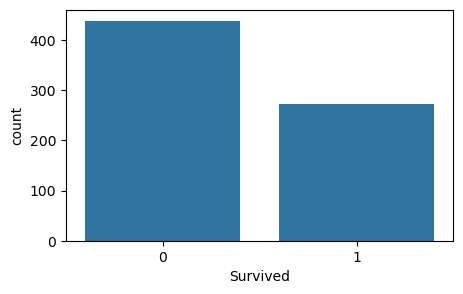

Global Survival Rate: 0.3834
Baseline Accuracy (if predicting majority class): 0.6166


In [13]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

#### Age

Derived domain-binned 'Age_Bin' feature based on non-linear age-survival relationship.
* Child: 0-10 years
* Teen: 10-17 years
* Young Adult: 17-35 years
* Middle Aged: 35-55 years
* Senior: 55-100 years

<Figure size 500x300 with 0 Axes>

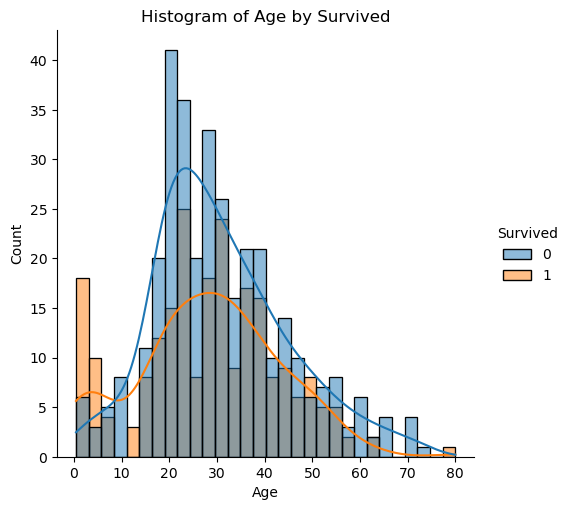

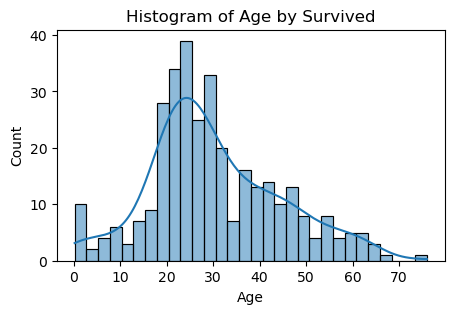

In [14]:
visualize_feature(X_train, 'Age', y_train)
visualize_feature(X_test, 'Age')

#### Fare

<Figure size 500x300 with 0 Axes>

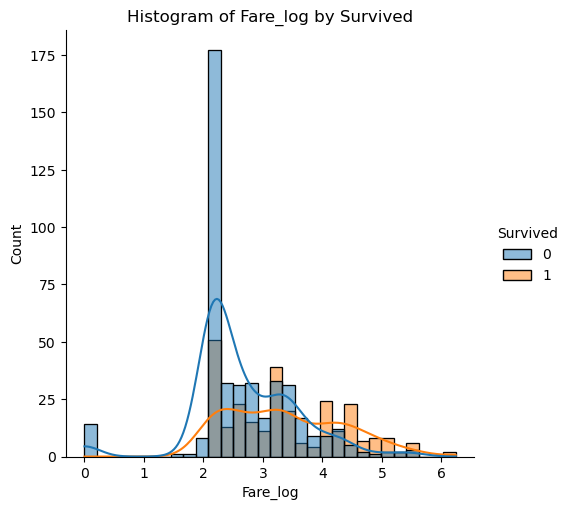

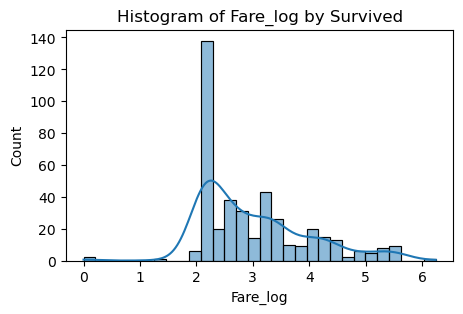

In [15]:
# Make copy of X_train/X_test and take Log1p of Fare to reduce skewness
# Make copy of only Fare column to avoid modifying original DataFrame
X_train_fare = X_train[['Fare']].copy()
X_train_fare['Fare_log'] = np.log1p(X_train_fare)

X_test_fare = X_test[['Fare']].copy()
X_test_fare['Fare_log'] = np.log1p(X_test_fare)

visualize_feature(X_train_fare, 'Fare_log', y_train)
visualize_feature(X_test_fare, 'Fare_log')  

# Ensure this feature is not used in model training directly to prevent data leakage
# log(Fare) must be done within pipeline to constrain calculation to training set only

#### Deck

* Sparse individual deck counts warrant binning to increase potential signal
* Analysis of class distribution across decks yielded the following groups:
    * `ABC`: 1st class only
    * `DE`: 1st class and some 2nd class
    * `Rare` : Lower and rarely occupied decks
    * `Unknown` : Deck letter unassigned

In [16]:
X_train_deck = X_train[['Cabin', 'Pclass']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
comb_df = pd.concat([X_train_deck, y_train], axis=1)
survival_df = (
    comb_df
    .groupby("Deck", observed=True)
    .agg(
        Survival_Rate=('Survived', 'mean'),
        Count=('Survived', 'size'),
        Pclass_1_Count=('Pclass', lambda x: (x == 1).sum()),
        Pclass_2_Count=('Pclass', lambda x: (x == 2).sum()),
        Pclass_3_Count=('Pclass', lambda x: (x == 3).sum())
    )
    .reset_index()
    .sort_values(by="Deck", ascending=True)
)
survival_df

,Deck,Survival_Rate,Count,Pclass_1_Count,Pclass_2_Count,Pclass_3_Count
0,A,0.428571,14,14,0,0
1,B,0.735294,34,34,0,0
2,C,0.682927,41,41,0,0
3,D,0.807692,26,23,3,0
4,E,0.758621,29,23,4,2
5,F,0.727273,11,0,8,3
6,G,0.500000,4,0,0,4
7,T,0.000000,1,1,0,0
8,Unknown,0.291667,552,35,135,382


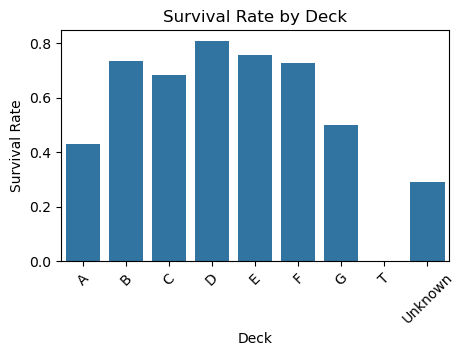

In [17]:
# Plot X_train Deck survival rate
def plot_deck_survival_rate(X_df, y_df):
    """
    Plots the survival rate by Deck.
    
    Parameters:
    - X_df: DataFrame containing the features
    - y_df: Series containing the target values
    """
    if 'Deck' not in X_df.columns:
        print("Deck feature not found in the DataFrame.")
        return
    
    deck_survival = pd.concat([X_df['Deck'], y_df], axis=1)
    deck_survival = deck_survival.groupby('Deck')['Survived'].mean().reset_index()
    
    plt.figure(figsize=(5, 3))
    sns.barplot(x='Deck', y='Survived', data=deck_survival)
    plt.title('Survival Rate by Deck')
    plt.xlabel('Deck')
    plt.ylabel('Survival Rate')
    plt.xticks(rotation=45)
    plt.show()

X_train_deck = X_train[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
plot_deck_survival_rate(X_train_deck, y_train)

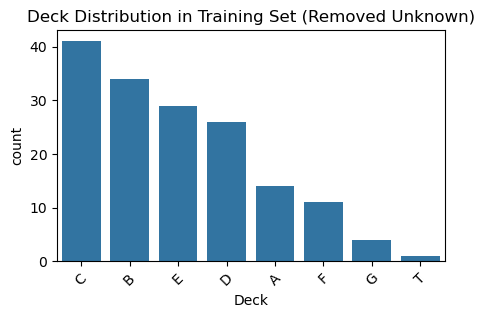

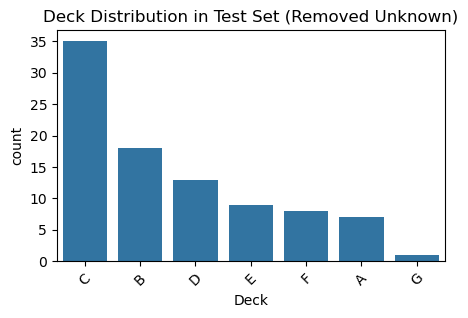

In [18]:
# Plot Train vs Test Deck values
X_train_deck = X_train[['Cabin']].copy()
X_test_deck = X_test[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0]
X_test_deck['Deck'] = X_test_deck['Cabin'].str[0]

plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_train_deck, order=X_train_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Training Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()  
plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_test_deck, order=X_test_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Test Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()

#### Family Size

Passenger family sizes have a non-linear relationship with survival:
* More passengers traveling alone perished rather than survived.
* Roughly equal number of passengers traveling with one family member perished and survived.
* More passengers with 2 or 3 family members survived rather than perished.
* Majority of passengers with 4 or more family members perished.

<Figure size 500x300 with 0 Axes>

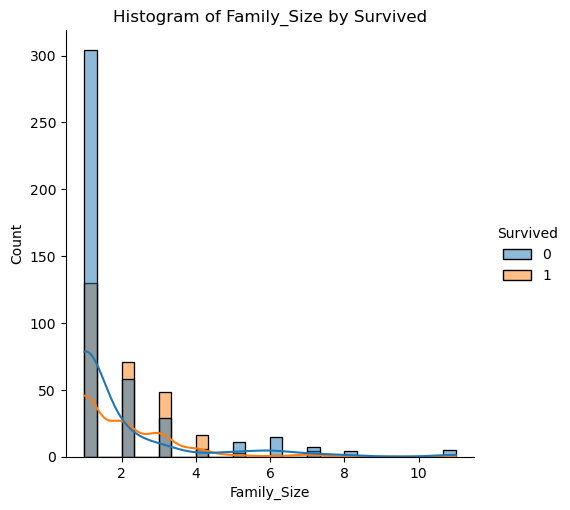

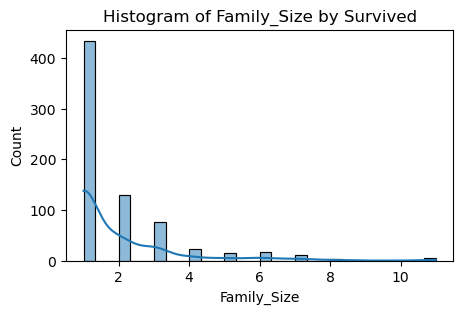

In [19]:
X_train_family_size = X_train[['Parch', 'SibSp']].copy()
X_train_family_size['Family_Size'] = X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1
visualize_feature(X_train_family_size, 'Family_Size', y_train)
visualize_feature(X_train_family_size, 'Family_Size')

#### Sex x Is_Alone

* Non-linear survival rates observed for passengers traveling alone or with family, across genders.
* Females with family survived at significantly higher rate (0.78) than males with family (0.27)

In [20]:
X_train_isalone_pclass = X_train[['Parch', 'SibSp', 'Sex']].copy()
X_train_isalone_pclass['Is_Alone'] = ((X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1) == 1).astype(int)
comb_df = pd.concat([X_train_isalone_pclass, y_train], axis=1)
# Pivot table: Survival Rate by Is_Alone and Pclass
pivot = comb_df.pivot_table(
    index='Is_Alone',
    columns='Sex',
    values='Survived',
    aggfunc='mean'
)
pivot = pivot.rename_axis('Is_Alone').rename_axis('Sex', axis=1)
pivot


Sex,female,male
Is_Alone,,
0,0.717105,0.269841
1,0.782178,0.153153


### Feature Engineering

#### Feature Creation

In [21]:
def engineer_features(df):

    # Create Sex_Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Deck_Bin feature
    def bin_deck(deck):
        if deck in ['A', 'B', 'C']:
            return 'Upper'
        elif deck in ['D', 'E']:
            return 'Middle'
        elif deck in ['F', 'G', 'T']:
            return 'Rare'
        else:
            return 'Unknown Deck'
    df['Deck_Bin'] = df['Deck'].apply(bin_deck)

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    #non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    #print("Non-numeric Ticket Numbers in training data:")
    #print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size <= 2:
            return f"{size}"
        elif size <= 4:
            return '3-4'
        else:
            return '5+'
    df['Family_Size_Bin'] = df['Family_Size'].apply(bin_family_size)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)
    df['HasCabin'] = (df['Cabin_Count'] > 0).astype(int)

    # Create Cabin Number feature
    # If feature contains multiple numbers, use the first one
    # If feature contains no numbers, set to NaN    
    df['Cabin_Number'] = df['Cabin'].str.extract(r'[A-Z](\d+)').astype('Int64')
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)


    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        return 'Starboard' if cabin_number % 2 == 0 else 'Port'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    df['Is_Child'] = (df['Age'] < 10).astype(int)

    df['Is_Loner_P3_Male_Southampton'] = ((df['Is_Alone'] == 1) & (df['Pclass'] == 3) & (df['Sex']=='male') & (df['Embarked'] == 'S')).astype(int)

    df['Is_P3_Loner_Male'] = ((df['Is_Alone'] == 1) & (df['Pclass'] == 3) & (df['Sex'] == 'male')).astype(int)

    df['Is_P1_Loner_Male'] = ((df['Is_Alone'] == 1) & (df['Pclass'] == 1) & (df['Sex'] == 'male')).astype(int)

    df['Sex_IsAlone'] = df['Sex'].astype(str) + '_' + df['Is_Alone'].astype(str)

    df['Pclass_Sex'] = df['Pclass'].astype(str) + '_' + df['Sex'].astype(str)

    return df


In [22]:
X_train = engineer_features(X_train)
X_test = engineer_features(X_test)
X_dev = engineer_features(X_dev)

In [23]:
X_train['Is_P1_Loner_Male'].value_counts()

Is_P1_Loner_Male
0    651
1     61
Name: count, dtype: int64

#### Pipeline Imputers

* Mode and median calculations are used to impute the missing `Embarked` and `Age` values.
* Custom imputer classes are created so that the calculations are confined to only the training set/fold when evaluating models during Training and Cross Validation.

In [24]:
class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        df = pd.DataFrame(X).copy()
        # compute medians on training fold only
        self.pclass_title_median_ = (
            df.groupby(['Pclass','Title'])['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        self.sex_median_ = (
            df.groupby('Sex')['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()

        # helper to look up from pclass_title_median_
        def fill_pt(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = (
                (self.pclass_title_median_['Pclass']==row['Pclass']) &
                (self.pclass_title_median_['Title']==row['Title'])
            )
            val = self.pclass_title_median_[mask]['median']
            return float(val.iloc[0]) if not val.empty else row['Age']

        df['Age'] = df.apply(fill_pt, axis=1)

        # fallback to sex median
        def fill_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = self.sex_median_['Sex']==row['Sex']
            return float(self.sex_median_[mask]['median'].iloc[0])
        df['Age'] = df.apply(fill_sex, axis=1)
        return df #[['Age']]
    
# NOTE: AgeBinner will pass through 'Age' as well as any column not specified in 'drop_cols'
class AgeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bins, labels=None, drop_cols=None, right=True):
        """
        bins : list of edges, e.g. [0, 10, 17, 35, 55, np.inf]
        labels : list of labels of length len(bins)-1
        right : whether intervals include the right edge
        """
        self.bins = bins
        self.labels = labels
        self.right = right
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        # nothing to learn
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()
        # apply pd.cut to the 'Age' column
        df['Age_Bin'] = pd.cut(
            df['Age'],
            bins=self.bins,
            labels=self.labels,
            right=self.right
        )
        if self.drop_cols is not None:
            # Drop specified columns to prevent them from being OHEC'd later
            df.drop(columns=self.drop_cols, inplace=True)
        return df

class EmbarkedImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # no hyper‐parameters here
        pass

    def fit(self, X, y=None):
        """
        X: array‐like or DataFrame with columns ['Pclass','Embarked']
        """
        df = pd.DataFrame(X, columns=['Pclass','Embarked'])
        # compute the mode of Embarked for each Pclass
        # .mode() returns a Series (possibly multiple modes), so take the first [0]
        self.pclass_mode_ = (
            df
            .dropna(subset=['Embarked'])
            .groupby('Pclass')['Embarked']
            .agg(lambda s: s.mode().iloc[0])
            .to_dict()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=['Pclass','Embarked']).copy()

        def _fill(row):
            if pd.notna(row['Embarked']):
                return row['Embarked']
            # lookup the Pclass‐mode, or fall back to overall mode
            return self.pclass_mode_.get(row['Pclass'],
                                        max(self.pclass_mode_.values(),
                                            key=lambda v: list(self.pclass_mode_.values()).count(v))
                                       )

        df['Embarked'] = df.apply(_fill, axis=1)
        return df

class TicketFrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ticket_counts_ = None

    def fit(self, X, y=None):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        self.ticket_counts_ = X_df['Ticket'].value_counts().to_dict()
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        X_df['Ticket_Frequency'] = X_df['Ticket'].map(self.ticket_counts_).fillna(1)
        return X_df[['Fare', 'Ticket_Frequency']]

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class FarePerPersonTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.is_fitted_ = True  # Flag to indicate to framework that this transformer is fitted (needs at least one attr ending with '_')
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Fare', 'Ticket_Frequency'])
        X_df['Fare_Per_Person'] = np.log1p(X_df['Fare']) / X_df['Ticket_Frequency'].replace(0, 1)
        return X_df[['Fare_Per_Person', 'Ticket_Frequency']]

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, drop_features=None):
        self.drop_features = drop_features or []
        self.keep_indices_ = None

    def fit(self, X, y=None):
        # If X is a DataFrame, we can directly use column names
        if hasattr(X, 'columns'):
            feature_names = X.columns
        else:
            # Try to get feature names from the input estimator
            # This is typically passed manually from preprocessor.get_feature_names_out()
            if hasattr(self, 'input_feature_names_'):
                feature_names = self.input_feature_names_
            else:
                raise ValueError("FeatureDropper requires DataFrame input or .input_feature_names_ to be set.")

        self.keep_indices_ = [i for i, name in enumerate(feature_names) if name not in self.drop_features]
        return self

    def transform(self, X):
        print(f"✂️ Dropping features: {self.drop_features}")
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.drop_features)
        elif isinstance(X, np.ndarray):
            return X[:, self.keep_indices_]
        elif hasattr(X, 'toarray'):
            return X[:, self.keep_indices_].toarray()
        else:
            raise TypeError(f"Unsupported input type. Expected DataFrame or NumPy array: {type(X)}")

    def set_input_feature_names(self, feature_names):
        self.input_feature_names_ = feature_names  

class MultiColumnBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bin_specs, input_features=None):
        """
        bin_specs: dict of format
        {
            'column_name': {
                'bins': [...],
                'labels': [...]
            }
        }
        input_features: list of column names (used to convert ndarray to DataFrame)
        """
        self.bin_specs = bin_specs
        self.input_features = input_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert ndarray to DataFrame using provided column names
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        elif self.input_features is not None:
            X_df = pd.DataFrame(X, columns=self.input_features)
        else:
            raise ValueError("input_features must be provided when input is an ndarray")

        for col, spec in self.bin_specs.items():
            X_df[f"{col}_bin"] = pd.cut(
                X_df[col],
                bins=spec['bins'],
                labels=spec['labels'],
                include_lowest=True
            ).astype(str)

        return X_df[[f"{col}_bin" for col in self.bin_specs]]


In [25]:
exclusion_features = ['Name', 'Cabin', 'PassengerId', 'Ticket_Number']
meaningful_features = [feature for feature in X_train.columns.tolist() if feature not in exclusion_features]
print(f"Meaningful features: {meaningful_features}")

Meaningful features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Sex_Encoded', 'Deck', 'Deck_Bin', 'Title', 'Surname', 'Ticket_Prefix', 'Family_Size', 'Family_Size_Bin', 'Is_Alone', 'Cabin_Count', 'HasCabin', 'Cabin_Number', 'Cabin_Side', 'Cabin_Missing', 'Age_Missing', 'Is_Child', 'Is_Loner_P3_Male_Southampton', 'Is_P3_Loner_Male', 'Is_P1_Loner_Male', 'Sex_IsAlone', 'Pclass_Sex']


### Model Development

In [26]:
def get_feature_names_from_preprocessor(preprocessor, selected_features):
    """Extract feature names after preprocessing."""
    feature_names = []
    
    for name, transformer, features in preprocessor.transformers_:
        if name == 'scaler' or name == 'passthrough' or name == 'loner_p3_male_southampton':
            feature_names.extend(features)
        elif name == 'fpp':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out()
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'loner_p3_male_southampton_young_adult_pipeline':
            feature_names.extend(['Is_Loner_P3_Male_Southampton_Young_Adult'])
        elif name == 'p1_loner_male_young_adult_pipeline':
            feature_names.extend(['Is_P1_Loner_Male_Young_Adult'])
        elif name == 'sex_isalone_ohes_and_male_loner_teen_pipeline':
            feature_names.extend(['Sex_IsAlone_female_1', 'Sex_IsAlone_male_0', 'Sex_IsAlone_male_1', 'Sex_IsAlone_male_1_Teen'])
        elif name == 'onehot':
            if hasattr(transformer, 'get_feature_names_out'):
                ohe_names = transformer.get_feature_names_out(features)
                feature_names.extend(ohe_names)
            else:
                categories = []
                for i, feature in enumerate(features):
                    cats = transformer.categories_[i]
                    for cat in cats:
                        categories.append(f"{feature}_{cat}")
                feature_names.extend(categories)
        elif name == 'fare_log_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out(features)
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'age_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_age', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out()
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
            # ohe = transformer.named_steps.get('ohe_age', None)
            # categories = ohe.categories_[0] if ohe is not None else []
            # for cat in categories:
            #     feature_names.append(f"Age_Bin_{cat}")
        elif name == 'pclass_embarked_ohe' or name == 'pclass_sex_ohe':
            # This pipeline outputs one-hot encoded Pclass_Embarked
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_embarked', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'class_sex_embarked_age_isalone_pipeline' or name == 'pclass_isalone_ohe':
            ohe = transformer.named_steps.get('ohe', None)
            if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                feature_names.extend(ohe_names)
            else:
                categories = ohe.categories_ if ohe is not None else []
                for i, feature in enumerate(features):
                    for cat in categories[i]:
                        feature_names.append(f"{feature}_{cat}")
    return feature_names


In [27]:
def deduplicate_df_majority_label(df, target='target'):
    duplicates = df.duplicated(keep=False)
    print(f"\nOriginal Training Set: {len(df)} rows.")
    if duplicates.any():
        print(f"⚠️ Found {duplicates.sum()} duplicate rows in the training set after preprocessing.")
    else:
        print("✅ No duplicate rows found in the training set after preprocessing.")

    feature_columns = list(df.columns[:-1])  

    # def resolve_group(group):
    #     majority_target = group[target].mode().iloc[0]
    #     return pd.Series({target: majority_target})
    
    # resolved_df = (df.groupby(feature_columns, observed=True)
    #                 .apply(resolve_group, include_groups=False)
    #                 .reset_index())

    grouped_results = []
    for name, group in df.groupby(feature_columns, observed=True):
        resolved_target = group[target].mode().iloc[0]
        
        # Create a single row with all feature values plus resolved target
        if isinstance(name, tuple):
            row_dict = dict(zip(feature_columns, name))
        else:
            row_dict = {feature_columns[0]: name}
        row_dict[target] = resolved_target
        grouped_results.append(row_dict)
    
    resolved_df = pd.DataFrame(grouped_results)
    
    print(f"✅ Resolved duplicates: {len(resolved_df)} unique rows after deduplication.")
    return resolved_df

In [28]:
class DupFreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Collapses duplicate rows in the training set and resolves conflicts by taking the majority class.
    This is useful to prevent information leakage from the holdout set during cross-validation.

    Assumes the base_estimator supports the sample_weight parameter.
    """
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def __getstate__(self):
        """Support for pickling"""
        state = self.__dict__.copy()
        return state
    
    def __setstate__(self, state):
        """Support for unpickling"""
        self.__dict__.update(state) 

    def get_params(self, deep=True):
        """Get parameters for this estimator and the wrapped estimator."""
        params = super().get_params(deep=False)
        if deep and hasattr(self, 'base_estimator'):
            base_params = self.base_estimator.get_params(deep=True)
            # Prefix base estimator parameters
            for key, value in base_params.items():
                params[f'base_estimator__{key}'] = value
        return params
    
    def set_params(self, **params):
        """Set parameters for this estimator and the wrapped estimator."""
        # Separate parameters for this wrapper vs the base estimator
        wrapper_params = {}
        base_params = {}
        
        for key, value in params.items():
            if key.startswith('base_estimator__'):
                # Remove prefix and set on base estimator
                base_key = key[len('base_estimator__'):]
                base_params[base_key] = value
            else:
                # Set on this wrapper
                wrapper_params[key] = value
        
        # Set base estimator parameters
        if base_params and hasattr(self, 'base_estimator'):
            self.base_estimator.set_params(**base_params)
        
        # Set wrapper parameters
        super().set_params(**wrapper_params)
        return self     
        
    def fit(self, X, y, **fit_params):
        #print(f"Fitting {self.__class__.__name__}...")
        try:
            if hasattr(X, 'toarray'):
                X_dense = X.toarray()
            else:
                X_dense = X

            # Mark as fitted for sklearn
            self.fitted_ = True  # Add this line

            df = pd.DataFrame(X_dense).copy()
            y_arr = np.asarray(y).ravel() 
            df['target'] = y_arr

            dedupe = fit_params.pop('dedupe', True)
            if  dedupe == True:
                print("Dedupe flag is set. Checking for duplicates in the training set...")

                # TODO If needed, use a more robust method than majority label to resolve duplicates
                df = deduplicate_df_majority_label(df)
            else:
                print("Deduplication deactivated. No deduplication performed.")
            feature_columns = list(df.columns[:-1])
            X_clean = df[feature_columns].copy()
            y_clean = df['target'].values

            print(f"Saving clean training set for later use... ({len(X_clean)} rows, {len(feature_columns)} features)")
            self.train_X_clean_ = X_clean.copy()

            self.estimator_ = clone(self.base_estimator)
            self.estimator_.fit(X_clean, y_clean, **fit_params)
            return self
        except Exception as e:
            print(f"Error during fitting {self.__class__.__name__}: {e}")
            raise

    def predict(self, X):
        print(f"Saving clean predicted set for post-analysis... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        print(f"Saving clean predicted set for post-analysis... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict_proba(X)

    def __getattr__(self, name):
        try:
            #print(f"Accessing attribute '{name}' of {type(self).__name__}")
            if 'estimator_' in self.__dict__:
                retval = getattr(self.estimator_, name)
                #print(f"Returning attribute '{name}' from estimator: {retval}")
                return retval
            elif 'base_estimator' in self.__dict__:
                retval = getattr(self.base_estimator, name)
                #print(f"Returning attribute '{name}' from base_estimator: {retval}")
                return retval
            else:
                #print(f"Attribute '{name}' not found in {type(self).__name__} or its base_estimator.")
                raise AttributeError(f"'{type(self).__name__}' object has no attribute '{name}'")
        except Exception as e:
            #print(f"Error accessing attribute '{name}': {e}")
            raise e

In [29]:
def evaluate_on_deduplicated_data(pipeline, X, y, selected_features, threshold=None, training_baseline_metrics=None, skip_visualizations=False):
    print("\n" + "="*50)
    print("PREDICTION EVALUATION ON DEDUPLICATED DATA")
    print("="*50)

    # Combine X and y into a DataFrame
    df = pd.DataFrame(X[selected_features]).copy()
    df['y_true'] = y

    # Deduplicate by feature columns, resolving conflicts by taking mode of y
    grouped = df.groupby(selected_features, sort=False)['y_true'].agg(lambda x: x.mode().iloc[0])
    X_dedup = grouped.index.to_frame(index=False).reset_index(drop=True)
    y_dedup = grouped.reset_index(drop=True)

    print(f"\nOriginal Prediction Set: {len(X)} rows.")
    print(f"✅ Deduplicated data: {len(X_dedup)} unique rows after deduplication post-processing.")

    # Predict using the pipeline
    y_pred_proba = pipeline.predict_proba(X_dedup)[:, 1]
    if threshold is not None:
        mlflow.log_param("proba_threshold", threshold)
        print(f"Using threshold: {threshold:.3f}")
        y_pred = (y_pred_proba >= threshold).astype(int)
    else:
        y_pred = pipeline.predict(X_dedup)

    if skip_visualizations is not True:
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_dedup, y_pred, target_names=['Not Survived', 'Survived'], zero_division=0))

        # Confusion matrix
        cm = confusion_matrix(y_dedup, y_pred, normalize='true')
        cm_counts = confusion_matrix(y_dedup, y_pred)
        mlflow.log_metric("cm_false_positive_pct", cm[0, 1])
        mlflow.log_metric("cm_false_negative_pct", cm[1, 0])

        # Annotate with both percent and count
        annot = np.empty_like(cm).astype(str)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i, j] = f"{cm[i, j]:.2%}\n({cm_counts[i, j]})"

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                    xticklabels=['Not Survived', 'Survived'],
                    yticklabels=['Not Survived', 'Survived'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix\n(Percent, Count)')
        plt.show()

    # Compute metrics
    metrics = {
        'log_loss': log_loss(y_dedup, y_pred_proba),
        'roc_auc': roc_auc_score(y_dedup, y_pred_proba),
        'pr_auc': average_precision_score(y_dedup, y_pred_proba),
        'f1': f1_score(y_dedup, y_pred, average='macro', zero_division=0),
        'precision': precision_score(y_dedup, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_dedup, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_dedup, y_pred),
    }
    mlflow.log_metrics(metrics)

    print("\n📈 Model Scores:")
    if training_baseline_metrics is not None:
        log_loss_diff = metrics['log_loss'] - training_baseline_metrics['log_loss']
        print(f"Log Loss: {metrics['log_loss']:.4f} (Diff from Baseline: {log_loss_diff:.4f})")
        pr_auc_diff = metrics['pr_auc'] - training_baseline_metrics['pr_auc']
        print(f"PR AUC: {metrics['pr_auc']:.4f} (Diff from Baseline: {pr_auc_diff:.4f})")
        roc_auc_diff = metrics['roc_auc'] - training_baseline_metrics['roc_auc']
        print(f"ROC AUC: {metrics['roc_auc']:.4f} (Diff from Baseline: {roc_auc_diff:.4f})")
        f1_diff = metrics['f1'] - training_baseline_metrics['f1']
        print(f"F1 Score: {metrics['f1']:.4f} (Diff from Baseline: {f1_diff:.4f})")
        precision_diff = metrics['precision'] - training_baseline_metrics['precision']
        print(f"Precision: {metrics['precision']:.4f} (Diff from Baseline: {precision_diff:.4f})")
        recall_diff = metrics['recall'] - training_baseline_metrics['recall']
        print(f"Recall: {metrics['recall']:.4f} (Diff from Baseline: {recall_diff:.4f})")
        accuracy_diff = metrics['accuracy'] - training_baseline_metrics['accuracy']
        print(f"Accuracy: {metrics['accuracy']:.4f} (Diff from Baseline: {accuracy_diff:.4f})")
        
        variance_metrics = {
            'log_loss_diff': log_loss_diff,
            'pr_auc_diff': pr_auc_diff,
            'roc_auc_diff': roc_auc_diff,
            'f1_diff': f1_diff,
            'precision_diff': precision_diff,
            'recall_diff': recall_diff,
            'accuracy_diff': accuracy_diff
        }
        mlflow.log_metrics(variance_metrics)

    else:
        print(f"Log Loss: {metrics['log_loss']:.4f}")
        print(f"PR AUC: {metrics['pr_auc']:.4f}")
        print(f"ROC AUC: {metrics['roc_auc']:.4f}")
        print(f"F1 Score: {metrics['f1']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")

    ################## PR Curve + PR AUC
    precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
    avg_precision = average_precision_score(y_dedup, y_pred_proba)

    if skip_visualizations is not True:
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, label=f'PR Curve (AP = {avg_precision:.3f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall (PR) Curve')
        plt.grid(True)
        plt.legend()
        plt.show()

        precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid div-by-zero
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]

        print(f"ℹ️ Best threshold for F1 score: {best_threshold:.3f}")
        print(f"Max F1 score: {f1_scores[best_idx]:.3f}")

        ################## ROC Curve + ROC AUC
        fpr, tpr, thresholds = roc_curve(y_dedup, y_pred_proba)
        auc = roc_auc_score(y_dedup, y_pred_proba)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend()
        plt.grid(True)
        plt.show()

    return metrics, pipeline.named_steps['classifier'].predicted_X_clean, y_dedup, y_pred, y_pred_proba

#### Stage 1: Bias Optimization

In [30]:
mlflow.set_tracking_uri('http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/')
#mlflow.set_tracking_uri('http://localhost:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')
ohe_features = ['Family_Size_Bin'] 
selected_features = ['Pclass_Sex', 'Deck_Bin', 'Sex_IsAlone', 'Is_P1_Loner_Male', 'Is_P3_Loner_Male', 'Is_Loner_P3_Male_Southampton', 'Is_Alone', 'Ticket', 'HasCabin', 'Pclass', 'Sex', 'Age', 'Fare', 'Title', 'Embarked'] + ohe_features 


PREPROCESSING AND TRAINING
Preprocessor will generate 172 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 712 rows.
⚠️ Found 491 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 281 unique rows after deduplication.
Saving clean training set for later use... (281 rows, 172 features)

Checking for multicollinearity in the processed training set...
⚠️ High Correlation Pairs (|r| > 0.8):
* Pclass_Embarked_1_Q and Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_female_Q_Young_Adult_0_1_Upper: 1.00

Preprocessor generated the following 172 features:
* Ticket_Frequency_bin_Shared
* Ticket_Frequency_bin_Unique
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_M

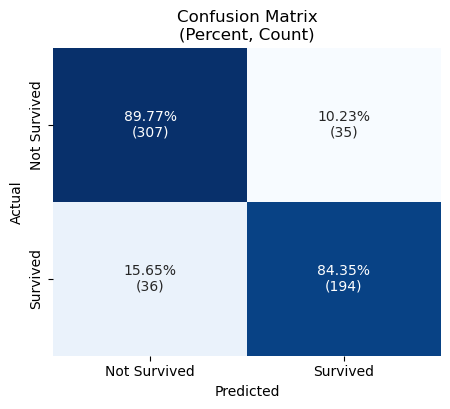


📈 Model Scores:
Log Loss: 0.3539
PR AUC: 0.9057
ROC AUC: 0.9115
F1 Score: 0.8708
Precision: 0.8711
Recall: 0.8706
Accuracy: 0.8759


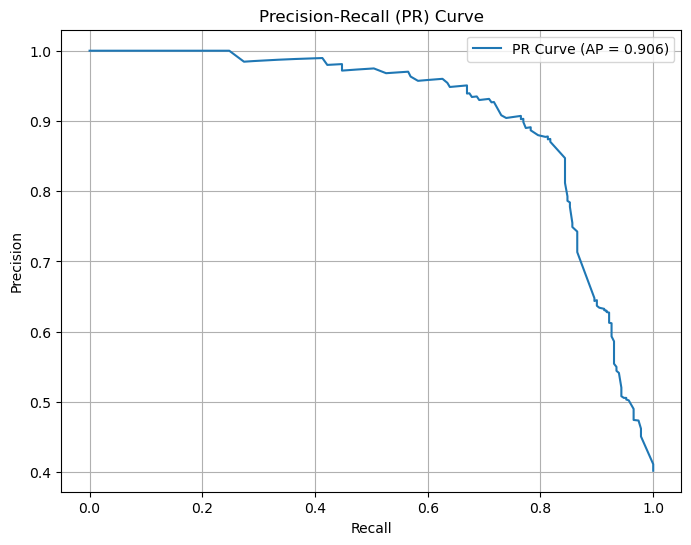

ℹ️ Best threshold for F1 score: 0.366
Max F1 score: 0.845


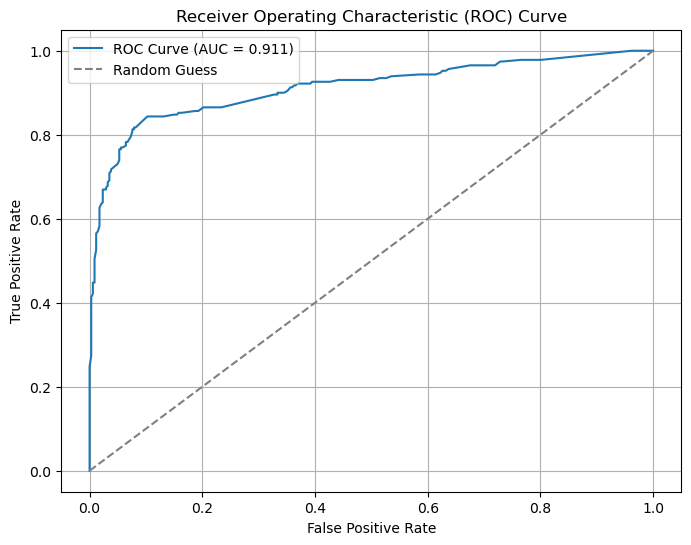


Non-Zero Coefficients:
                                                    Coefficient
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_3_...     1.968645
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_...     1.916662
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_...     1.775602
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_3_...     1.647647
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_3_...     1.636190
...                                                         ...
Pclass_Embarked_3_S                                   -2.030107
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_...    -2.054626
Age_Bin_Senior                                        -2.150116
Sex_IsAlone_male_0                                    -2.245255
Sex_IsAlone_male_1                                    -2.274051

[172 rows x 1 columns]


c:\Users\pault\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


🏃 View run amazing-trout-433 at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/4b5e0caece4f4397996597fa82bfdc1a
🧪 View experiment at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3


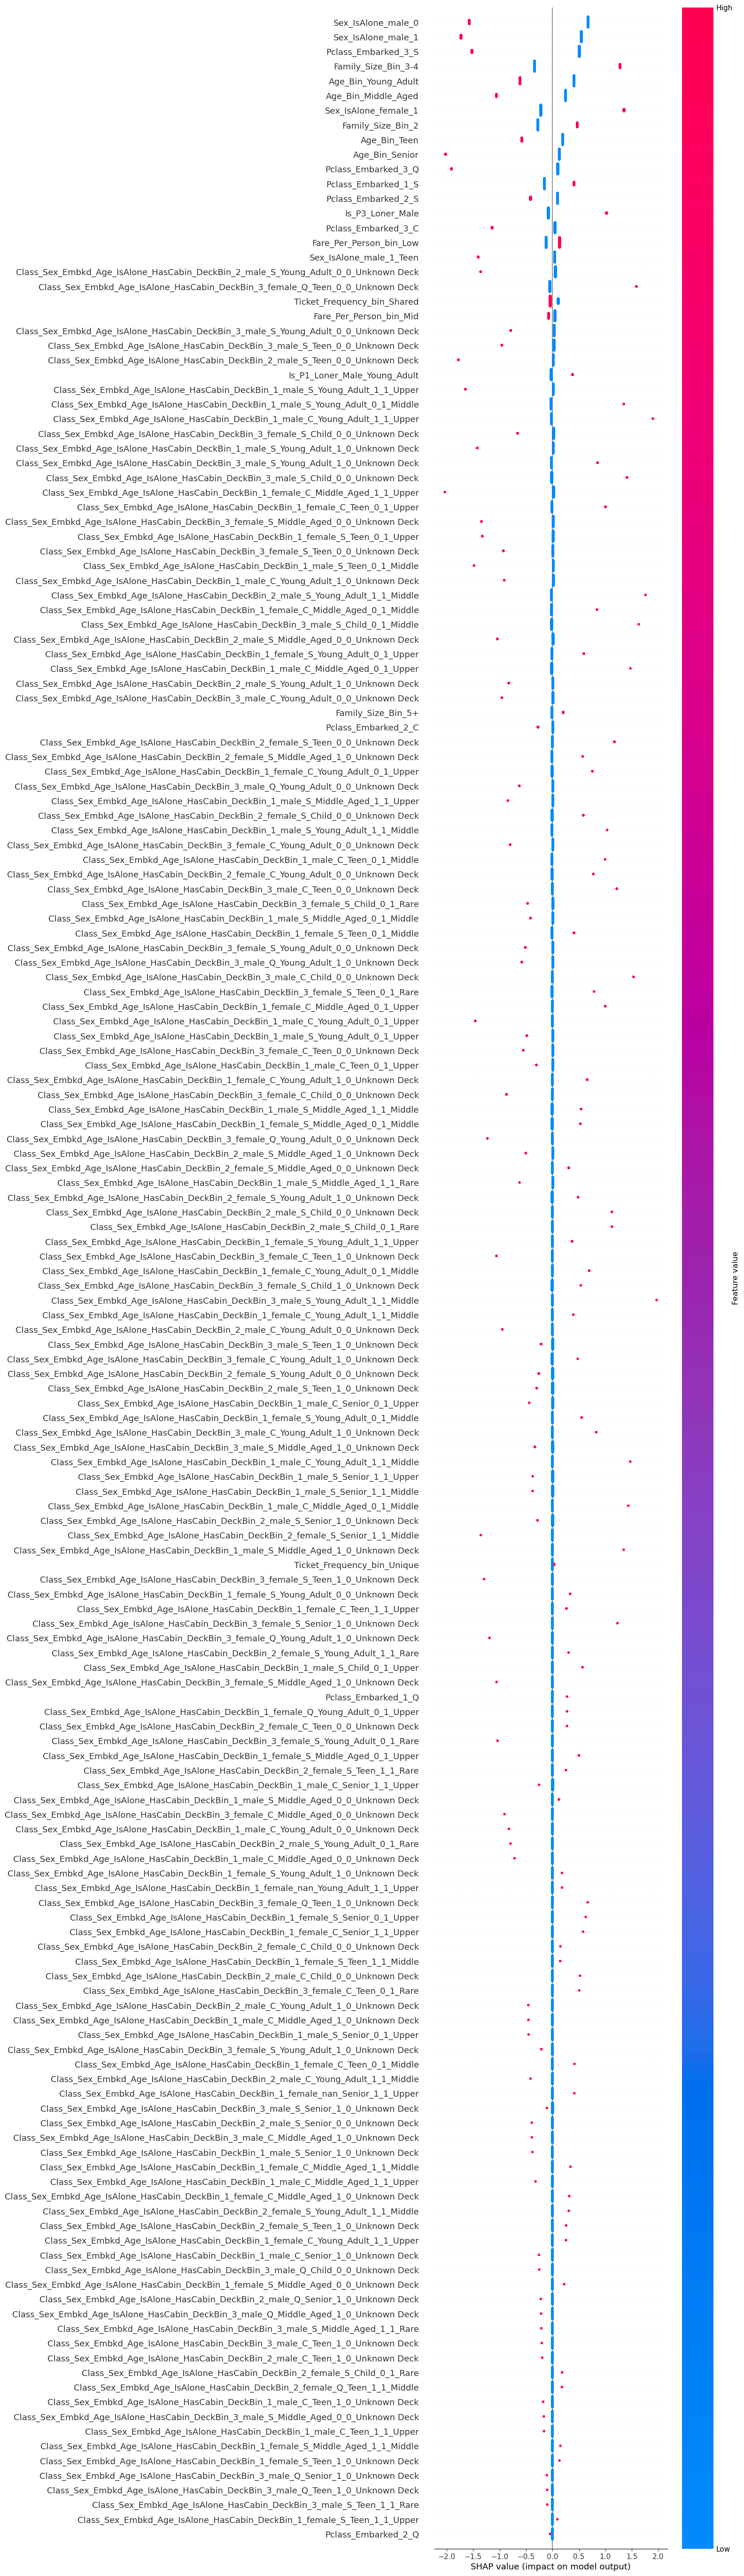

In [31]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_train")

    print("\n" + "="*50)
    print("PREPROCESSING AND TRAINING")
    print("="*50)

    bin_specs = {
        'Ticket_Frequency': {
            'bins': [-float('inf'), 0.5, 2, float('inf')],
            'labels': ['Shared', 'Group', 'Unique']
        },
        'Fare_Per_Person': {
            'bins': [-float('inf'), 0.0, 1.0, float('inf')],
            'labels': ['Low', 'Mid', 'High']
        }
    }

    fare_enrichment_pipeline = Pipeline([
        ('ticket_freq', TicketFrequencyEncoder()),
        ('fare_per_person', FarePerPersonTransformer()),
        ('scaler', StandardScaler()),
        ('ticketfreq_fpp_binning', MultiColumnBinner(bin_specs=bin_specs, input_features=['Ticket_Frequency', 'Fare_Per_Person'])),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first')) 
    ])

    def create_pclass_embarked_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Embarked'])
        df['Pclass_Embarked'] = df['Pclass'].astype(str) + '_' + df['Embarked'].astype(str)
        return df[['Pclass_Embarked']]
    pclass_embarked_pipeline = Pipeline([
        ('impute_embarked', EmbarkedImputer()),
        ('create_pclass_embarked', FunctionTransformer(create_pclass_embarked_feature, validate=False)),
        ('ohe_embarked',    OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    bins = [0, 10, 25, 40, 55, 100]
    mlflow.log_param("age_bins", bins)
    labels = ['Child', 'Teen', 'Young_Adult', 'Middle_Aged', 'Senior']
    age_pipeline_cols = ['Pclass', 'Title', 'Sex', 'Age']
    age_pipeline = Pipeline([
        ('impute_age', AgeImputer()),  
        ('bin_age', AgeBinner(bins=bins, labels=labels, drop_cols=age_pipeline_cols)),
        ('ohe_age', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    
    def create_pclass_sex_embarked_age_bin_isalone_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Sex', 'Embarked', 'Age_Bin', 'Is_Alone', 'HasCabin', 'Deck_Bin'])
        df['Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin'] = df['Pclass'].astype(str) + '_' + df['Sex'].astype(str) + '_' + df['Embarked'].astype(str) + '_' + df['Age_Bin'].astype(str) + '_' + df['Is_Alone'].astype(str) + '_' + df['HasCabin'].astype(str) + '_' + df['Deck_Bin'].astype(str)
        return df[['Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin']] 
    class_sex_embarked_age_isalone_pipeline = Pipeline([
        ('impute_age', AgeImputer()),  
        ('bin_age',    AgeBinner(bins=bins, labels=labels, drop_cols=['Age', 'Title'])),
        ('create_pclass_sex_embarked_age_bin_isalone', FunctionTransformer(create_pclass_sex_embarked_age_bin_isalone_feature, validate=False)),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    p1_loner_pipeline = Pipeline([
        ('select_p1_loner', FunctionTransformer(
            lambda df: pd.DataFrame(df['Is_P1_Loner_Male'], columns=[]),
            validate=False
        ))
    ])
    combined_p1_loner_age_features = FeatureUnion([
        ('loner', p1_loner_pipeline),
        ('age_pipeline', age_pipeline)
    ])
    def create_p1_loner_male_young_adult_feature(X):
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()  # Convert sparse matrix to dense
        elif isinstance(X, np.ndarray):
            X_dense = X
        else:
            X_dense = np.array(X)
        expected_cols = ['Is_P1_Loner_Male', 'Age_Bin_Middle_Aged', 'Age_Bin_Senior', 'Age_Bin_Teen', 'Age_Bin_Young_Adult']
        df = pd.DataFrame(X_dense, columns=expected_cols[:X_dense.shape[1]])
        df['Is_P1_Loner_Male_Young_Adult'] = ((df['Is_P1_Loner_Male'] == 1) & (df['Age_Bin_Young_Adult'] == 1)).astype(int)
        return df[['Is_P1_Loner_Male_Young_Adult']] 
    p1_loner_male_young_adult_pipeline = Pipeline([
        ('combine_features', combined_p1_loner_age_features),
        ('create_interaction', FunctionTransformer(create_p1_loner_male_young_adult_feature, validate=False))
    ])

    def create_sex_isalone_ohe_and_male_loner_teen_features(X):
        if hasattr(X, 'toarray'):
            X_dense = X.toarray()  # Convert sparse matrix to dense
        elif isinstance(X, np.ndarray):
            X_dense = X
        else:
            X_dense = np.array(X)
        expected_cols = ['Sex_IsAlone_female_1', 'Sex_IsAlone_male_0', 'Sex_IsAlone_male_1', 
                         'Age_Bin_Middle_Aged', 'Age_Bin_Senior', 'Age_Bin_Teen', 'Age_Bin_Young_Adult']
        df = pd.DataFrame(X_dense, columns=expected_cols[:X_dense.shape[1]])
        df['Sex_IsAlone_male_1_Teen'] = ((df['Sex_IsAlone_male_1'] == 1) & (df['Age_Bin_Teen'] == 1)).astype(int)
        return df[['Sex_IsAlone_female_1', 'Sex_IsAlone_male_0', 'Sex_IsAlone_male_1', 'Sex_IsAlone_male_1_Teen']] 
    sex_isalone_ohes_and_male_loner_teen_pipeline = Pipeline([
        ('age_pipeline', age_pipeline),  # Receives and OHEs 'Sex_IsAlone' as well
        ('create_interaction', FunctionTransformer(create_sex_isalone_ohe_and_male_loner_teen_features, validate=False))
    ])

    preprocessor = ColumnTransformer([
        ('fpp', fare_enrichment_pipeline, ['Ticket', 'Fare']),
        ('pclass_embarked_ohe', pclass_embarked_pipeline, ['Pclass', 'Embarked']),
        ('age_ohe', age_pipeline, age_pipeline_cols),
        ('class_sex_embarked_age_isalone_pipeline', class_sex_embarked_age_isalone_pipeline, age_pipeline_cols + ['Embarked', 'Is_Alone', 'HasCabin', 'Deck_Bin']),
        ('p1_loner_male_young_adult_pipeline', p1_loner_male_young_adult_pipeline, age_pipeline_cols + ['Is_P1_Loner_Male']),
        ('sex_isalone_ohes_and_male_loner_teen_pipeline', sex_isalone_ohes_and_male_loner_teen_pipeline, age_pipeline_cols + ['Sex_IsAlone']),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features),
        ('passthrough', 'passthrough', ['Is_P3_Loner_Male'])
    ])

    optimized_model_params = {'C': 3.488745421004247, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 509, 'penalty': 'l2', 'solver': 'liblinear'}

    preprocessor.fit(X_train)
    high_corr_features_to_drop = [
        'Deck_Bin_Unknown Deck',
        # 'Deck_Bin_Rare'
    ]
    feature_names_after_preprocessing = get_feature_names_from_preprocessor(preprocessor, selected_features)
    feature_names_after_preprocessing = [feat for feat in feature_names_after_preprocessing if feat not in high_corr_features_to_drop]
    print(f"Preprocessor will generate {len(feature_names_after_preprocessing)} features after preprocessing.")
    dropper = FeatureDropper(drop_features=high_corr_features_to_drop)
    dropper.set_input_feature_names(feature_names_after_preprocessing)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('dropper', dropper),
        ('classifier', DupFreeClassifier(LogisticRegression(**optimized_model_params, random_state=42)))
    ])

    mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)
    mlflow.log_params(optimized_model_params)

    # Defer calibrating model probabilities to Stage 2 (CV) given Stage 1 focus on model bias optimization
    pipeline.fit(X_train[selected_features], y_train)

    # Plot correlation matrix for fitted features to identify potential multicollinearity issues
    # Print feature pairs with high correlation (> 0.8)
    X_train_processed = pipeline.named_steps['classifier'].train_X_clean_
    X_train_processed.columns = feature_names_after_preprocessing
    print("\nChecking for multicollinearity in the processed training set...")
    correlation_matrix = X_train_processed.corr()
    high_corr_pairs = []
    for i in range(len(feature_names_after_preprocessing)):
        for j in range(i + 1, len(feature_names_after_preprocessing)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                high_corr_pairs.append((feature_names_after_preprocessing[i], feature_names_after_preprocessing[j], correlation_matrix.iloc[i, j]))
    if high_corr_pairs:
        print("⚠️ High Correlation Pairs (|r| > 0.8):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"* {feat1} and {feat2}: {corr:.2f}") 
    else:
        print("✅ No high correlation pairs found (|r| <= 0.8).") 

    print(f"\nPreprocessor generated the following {len(feature_names_after_preprocessing)} features:")
    for i, feat in enumerate(feature_names_after_preprocessing):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    baseline_metrics, X_predicted_csr_matrix, y_true, y_pred, y_pred_proba = evaluate_on_deduplicated_data(pipeline, X_train, y_train, selected_features, threshold=0.366)
 
    print("\nNon-Zero Coefficients:")
    coef_df = pd.DataFrame(pipeline.named_steps['classifier'].coef_.T, index=feature_names_after_preprocessing, columns=['Coefficient'])
    non_zero_coefs = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)
    zero_coefs = coef_df[coef_df['Coefficient'] == 0]
    print(non_zero_coefs)

    if optimized_model_params['penalty'] == 'l1':
        print("\nZeroed-out Coefficients:")
        print(zero_coefs)


    explainer = shap.LinearExplainer(pipeline.named_steps['classifier'], X_train_processed)
    shap_values = explainer.shap_values(X_train_processed)
    shap.summary_plot(shap_values, X_train_processed, plot_type="dot", show=False, max_display=len(X_train_processed.columns))

#### Training Set Prediction Mistake Analysis

* Confusion matrix shows model is able to classify 94% of negative class `Survived=0` but only 67% of positive class `Survived=1`.
* We take a closer look at the training samples where `Survived=1` to see what feature engineering we can introduce to help the model recognize survivors.

In [32]:
X_predicted_csr_matrix.shape, y_true.shape, y_pred.shape, y_pred_proba.shape

((572, 172), (572,), (572,), (572,))

In [33]:
# Filter y_train, y_pred, y_pred_proba to match X_train_processed
X_predicted = pd.DataFrame(X_predicted_csr_matrix, columns=feature_names_after_preprocessing)
training_prediction_results_df = pd.concat([
    X_predicted.reset_index(drop=True),
    pd.Series(y_true, name='y_true'),
    pd.Series(y_pred, name='y_pred'),
    pd.Series(y_pred_proba, name='y_pred_proba')
], axis=1)

training_prediction_results_df['Mistake'] = training_prediction_results_df['y_true'] !=  training_prediction_results_df['y_pred']
training_prediction_results_df['Mistake_Prob'] = np.abs(training_prediction_results_df['y_pred_proba'] - training_prediction_results_df['y_true'])
survived_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 1]
perished_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 0]
print(f"Mistake Rate of Perished Passengers: {perished_pred_results_df['Mistake'].mean():.2%} ({perished_pred_results_df['Mistake'].sum()})")
print(f"Mistake Rate of Survived Passengers: {survived_pred_results_df['Mistake'].mean():.2%} ({survived_pred_results_df['Mistake'].sum()})")

Mistake Rate of Perished Passengers: 10.23% (35)
Mistake Rate of Survived Passengers: 15.65% (36)


##### Correct vs Mistake Feature Distribution Comparison

Large spike in high-log-loss mistakes suggests model has blind spot to survival subgroup(s).

C:\Users\pault\AppData\Local\Temp\ipykernel_19036\2353809310.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


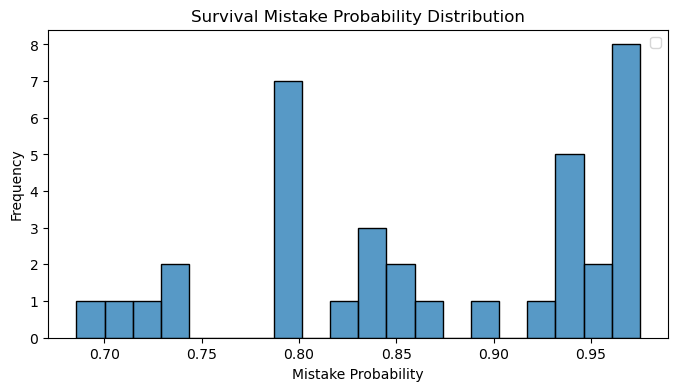

C:\Users\pault\AppData\Local\Temp\ipykernel_19036\2353809310.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


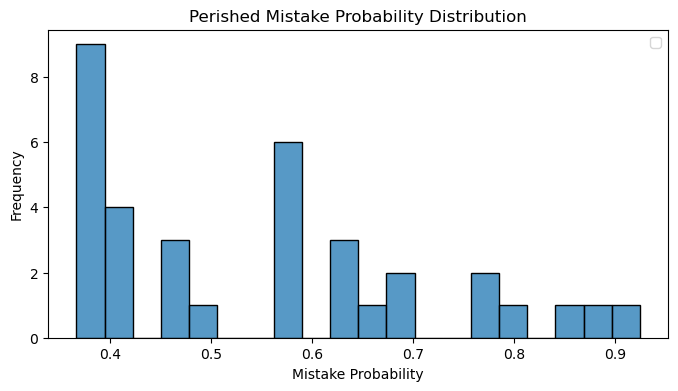

In [34]:
# Separate Mistakes from Correct Predictions for distribution comparison
survived_pred_results_df_mistakes = survived_pred_results_df[survived_pred_results_df['Mistake'] == True]
survived_pred_results_df_correct = survived_pred_results_df[survived_pred_results_df['Mistake'] == False]
perished_pred_results_df_mistakes = perished_pred_results_df[perished_pred_results_df['Mistake'] == True]
perished_pred_results_df_correct = perished_pred_results_df[perished_pred_results_df['Mistake'] == False]

# Probability Distribution of Mistaken Predictions of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(survived_pred_results_df_mistakes['Mistake_Prob'], bins=20)
plt.title('Survival Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Probability Distribution of Mistaken Predictions of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(perished_pred_results_df_mistakes['Mistake_Prob'], bins=20)
plt.title('Perished Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [35]:
# Separating highest-confidence mistakes `Mistake_Prob > 0.85` and 
# comparing distribution to Correct predictions to see if any differences
# high_confidence_mistakes = survived_pred_results_df_mistakes[survived_pred_results_df_mistakes['Mistake_Prob'] > 0.70]
# print(f"High-Confidence Mistakes: {len(high_confidence_mistakes)} ({high_confidence_mistakes['Mistake_Prob'].mean():.2%})")

# # Probability Distribution of High-Confidence Mistakes of Survived Passengers
# plt.figure(figsize=(8, 4))
# sns.histplot(high_confidence_mistakes['Mistake_Prob'], bins=20, color='orange')
# plt.title('High-Confidence Survival Mistake Probability Distribution')
# plt.xlabel('Mistake Probability')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()

##### Feature Predictiveness of High-Confidence Mistakes

A LogisticRegression model is trained with base features and `Mistake` as target in order to use coefficients to identify features that helped and hurt model predictiveness.

In [36]:
X = survived_pred_results_df[(survived_pred_results_df['Mistake'] == False) | (survived_pred_results_df['Mistake_Prob'] > 0.9)]  # Filter out low-confidence mistakes
y = X['Mistake'].astype(int)
X = X.drop(columns=['Mistake', 'Mistake_Prob', 'y_pred', 'y_pred_proba', 'y_true'])
lr = LogisticRegression(
                C=1.0, 
                class_weight='balanced', 
                fit_intercept=True, 
                max_iter=100, 
                penalty='l2', 
                
                solver='liblinear', 
                random_state=42
            )
lr.fit(X, y)

print("\nLogistic Regression Coefficients for Mistake Prediction:")
mistake_coef_df = pd.DataFrame(lr.coef_.T, index=X.columns, columns=['Coefficient'])
mistake_coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)
mistake_coef_df.head(20)


Logistic Regression Coefficients for Mistake Prediction:


,Coefficient
Sex_IsAlone_male_1,2.077477
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Young_Adult_0_0_Unknown Deck,1.754835
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_3_male_S_Teen_0_0_Unknown Deck,1.485025
Is_P3_Loner_Male,1.061851
Sex_IsAlone_male_0,1.052500
Sex_IsAlone_male_1_Teen,1.025408
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_male_C_Senior_1_1_Upper,0.823766
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Young_Adult_1_0_Unknown Deck,0.785812
Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Middle_Aged_1_0_Unknown Deck,0.767237
Pclass_Embarked_3_S,0.683773


In [37]:
# Compare feature distributions bewteen high-confidence mistakes and correct predictions
#combined_df = pd.concat([survived_pred_results_df_correct, high_confidence_mistakes], axis=0)
#survived_p3_male_southampton_teens = combined_df[combined_df['Class_Sex_Embkd_Age_3_male_S_Teen'] == 1]
# for feature in survived_p3_male_southampton_teens.columns:
#     plt.figure(figsize=(10, 4))
#     sns.kdeplot(data=survived_p3_male_southampton_teens, x=feature, hue='Mistake', common_norm=False, fill=True, warn_singular=False)
#     plt.title(f'Distribution of Survived P3 Male Southampton Teen {feature} by Mistake Status')
#     plt.xlabel(feature)
#     plt.ylabel('Density')
#     plt.legend(title='Mistake', labels=['Correct', 'High-Confidence Mistake'])
#     plt.show()



c:\Users\pault\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1153: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  pl.tight_layout()


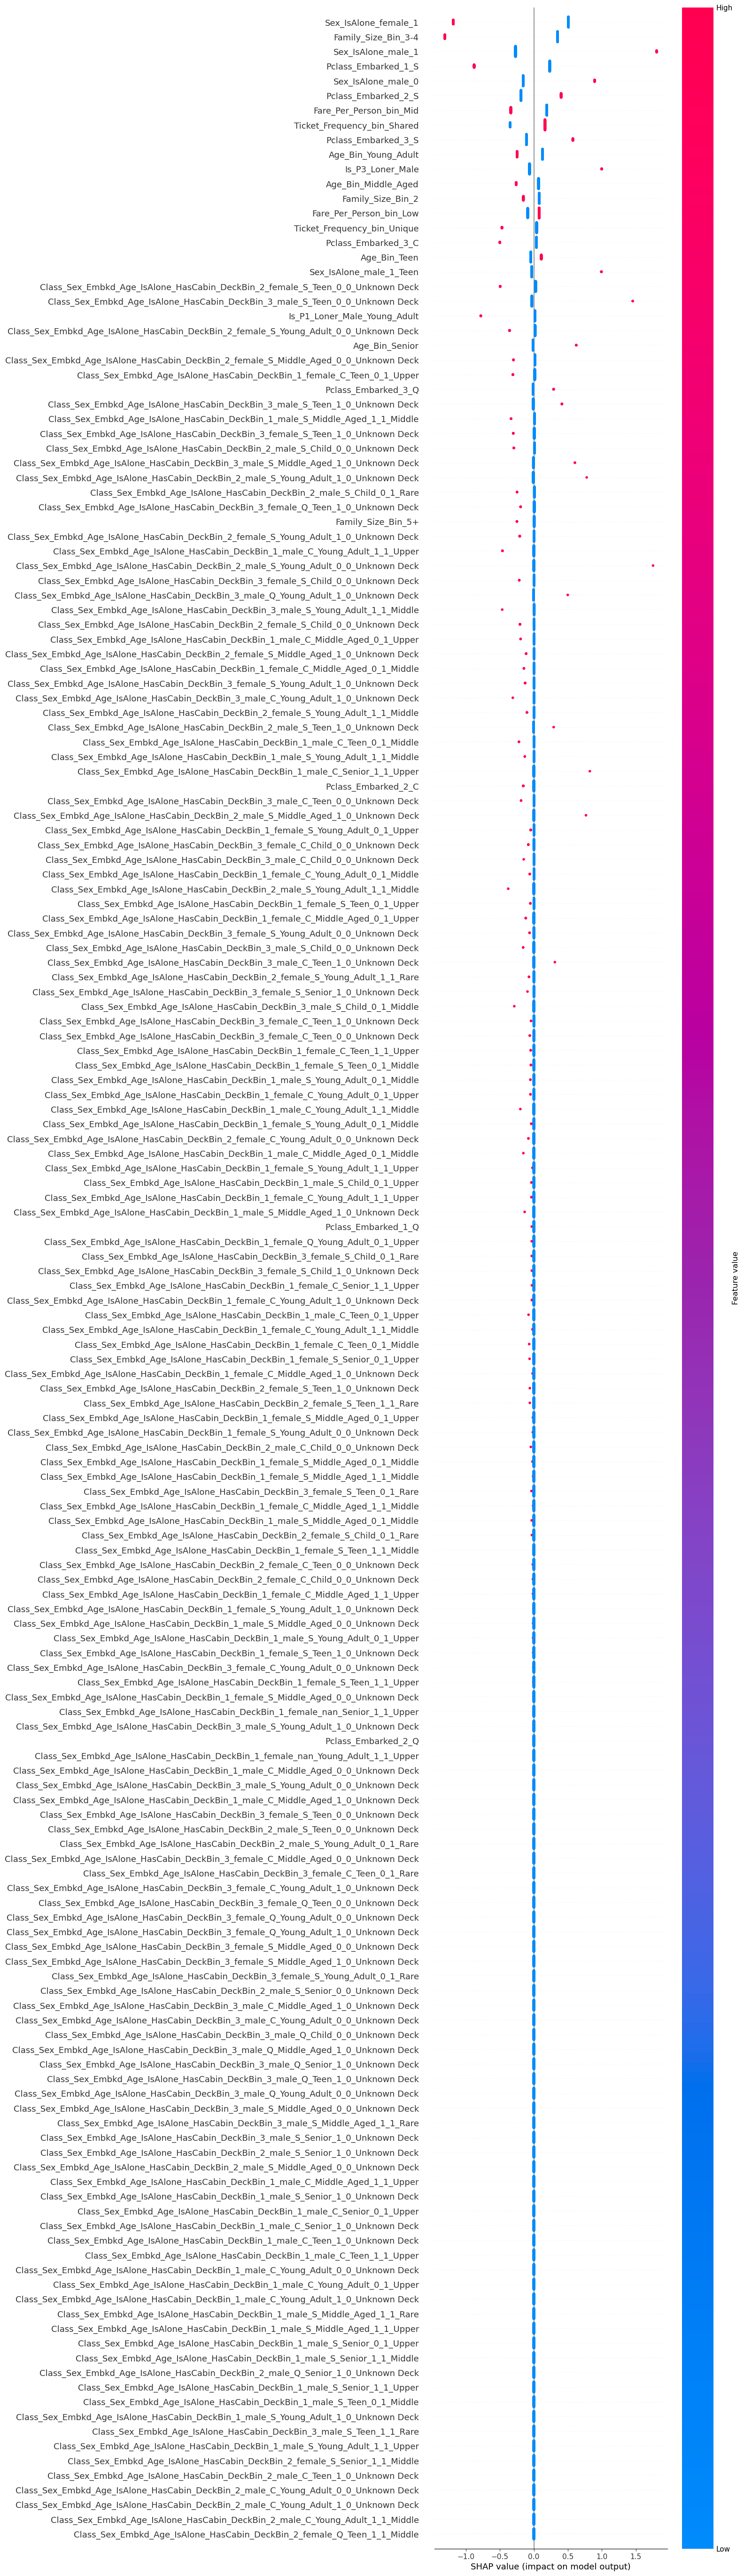

In [38]:
explainer = shap.LinearExplainer(lr, X)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="dot", show=False, max_display=len(X.columns))

##### Mistake EDA

SHAP Summary shows Mistake probability (Survived passengers predicted as perished) increased when the following features are True:
* `Sex_IsAlone_male_1`
* `Deck_Bin_Upper`
* `Class_Sex_Embkd_Age_IsAlone_HasCabin_3_female_S_Teen_0_0`
* `Class_Sex_Embkd_Age_IsAlone_HasCabin_2_male_S_Young_Adult_0_0`
* `Pclass_Embarked_3_S`
* `Pclass_Sex_2_male`
* `Family_Size_Bin_5+`
* `Pclass_Sex_3_male`

Let's explore combinations to search for new interactions to reduce these features' contribution to mistakes.

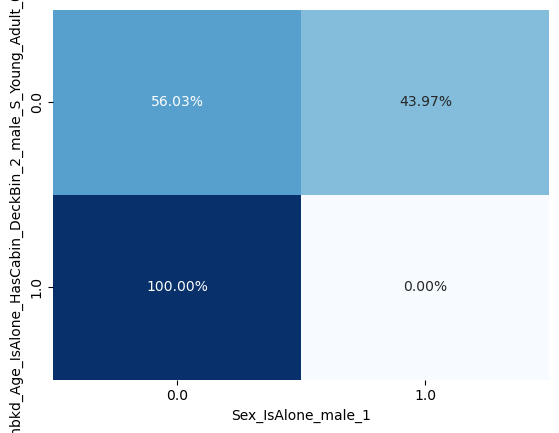

In [ ]:
crosstab = pd.crosstab(X_predicted['Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Young_Adult_0_0_Unknown Deck'], X_predicted['Sex_IsAlone_male_1'], normalize='index')
sns.heatmap(crosstab, annot=True, fmt='.2%', cmap='Blues', cbar=False)
plt.show()

In [40]:
X_predicted[['Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Young_Adult_0_0_Unknown Deck','Sex_IsAlone_male_1']].value_counts()


Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_2_male_S_Young_Adult_0_0_Unknown Deck  Sex_IsAlone_male_1
0.0                                                                                 0.0                   316
                                                                                    1.0                   248
1.0                                                                                 0.0                     8
Name: count, dtype: int64

#### Stage 2: Generalization Optimization


Fold 1/3


[I 2025-06-26 16:50:43,951] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_1



PREPROCESSING AND TRAINING
Preprocessor will generate 132 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 474 rows.
⚠️ Found 334 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 188 unique rows after deduplication.
Saving clean training set for later use... (188 rows, 132 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


[I 2025-06-26 16:50:45,143] Trial 0 finished with value: 0.6931471805599454 and parameters: {'C': 0.03145068067520579, 'class_weight': None, 'fit_intercept': True, 'max_iter': 106, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.6931471805599454.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.6931
PR AUC: 0.3979
ROC AUC: 0.5000
F1 Score: 0.2846
Precision: 0.1990
Recall: 0.5000
Accuracy: 0.3979
Preprocessor will generate 132 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 474 rows.
⚠️ Found 334 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 188 unique rows after deduplication.
Saving clean training set for later use... (188 rows, 132 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


...

Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.3755
PR AUC: 0.8886
ROC AUC: 0.8924
F1 Score: 0.8634
Precision: 0.8634
Recall: 0.8634
Accuracy: 0.8691
Preprocessor will generate 132 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 474 rows.
⚠️ Found 334 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 188 unique rows after deduplication.
Saving clean training set for later use... (188 rows, 132 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


[I 2025-06-26 16:51:18,780] Trial 28 finished with value: 0.41467087156614124 and parameters: {'C': 21.01246774860758, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 458, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 23 with value: 0.37537265933161257.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.4147
PR AUC: 0.8858
ROC AUC: 0.8890
F1 Score: 0.8605
Precision: 0.8609
Recall: 0.8601
Accuracy: 0.8665
Preprocessor will generate 132 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 474 rows.
⚠️ Found 334 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 188 unique rows after deduplication.
Saving clean training set for later use... (188 rows, 132 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


[I 2025-06-26 16:51:19,984] Trial 29 finished with value: 0.6426745427053686 and parameters: {'C': 0.09128216179896777, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 393, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 23 with value: 0.37537265933161257.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.6427
PR AUC: 0.6677
ROC AUC: 0.7884
F1 Score: 0.2846
Precision: 0.1990
Recall: 0.5000
Accuracy: 0.3979
Best Trial:
  Value (Log Loss): 0.3754
  Params:
    C: 4.343957901116486
    class_weight: balanced
    fit_intercept: True
    max_iter: 370
    penalty: l2
    solver: liblinear

Checking for multicollinearity in the processed training set...
⚠️ High Correlation Pairs (|r| > 0.8):
* Pclass_Embarked_1_Q and Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_female_Q_Young_Adult_0_1_Upper: 1.00

Preprocessor generated the following 172 features:
* Ticket_Frequency_bin_Shared
* Ticket_Frequency_bin_Unique
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Class_Sex_Embkd_Age_IsAlone_HasC

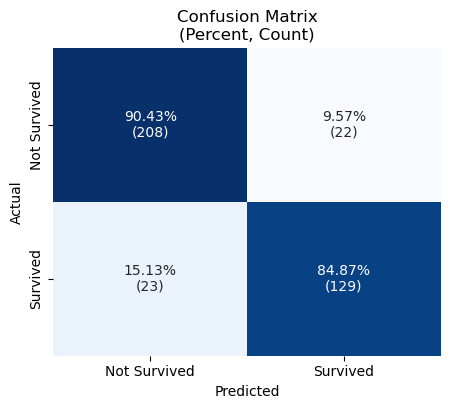


📈 Model Scores:
Log Loss: 0.3559 (Diff from Baseline: 0.0020)
PR AUC: 0.9050 (Diff from Baseline: -0.0007)
ROC AUC: 0.9101 (Diff from Baseline: -0.0014)
F1 Score: 0.8769 (Diff from Baseline: 0.0061)
Precision: 0.8774 (Diff from Baseline: 0.0063)
Recall: 0.8765 (Diff from Baseline: 0.0059)
Accuracy: 0.8822 (Diff from Baseline: 0.0063)


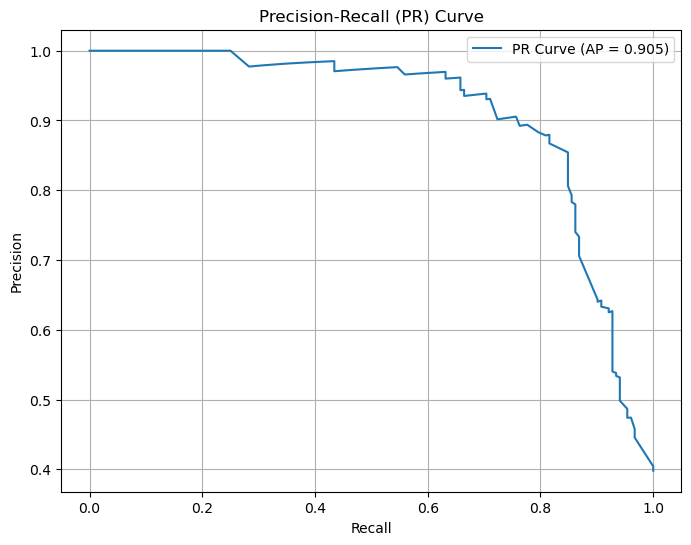

ℹ️ Best threshold for F1 score: 0.366
Max F1 score: 0.851


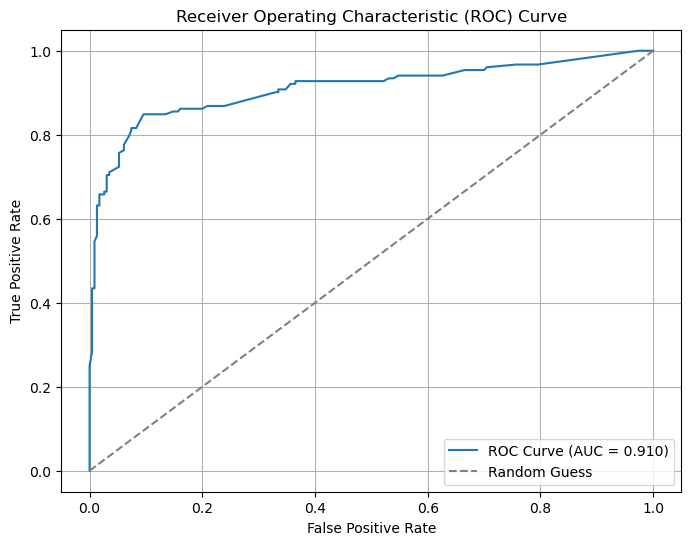

🏃 View run learned-asp-940 at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/87c2b2fdbbe941d3bed587536d48762f
🧪 View experiment at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3
CV Results:
[{'fold': 1, 'best_trial_params': {'C': 4.343957901116486, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 370, 'penalty': 'l2', 'solver': 'liblinear'}, 'log_loss': 0.3559392237153411, 'roc_auc': 0.9100543478260871, 'pr_auc': 0.9050380724416415, 'f1': 0.8769356328257554, 'precision': 0.877368768097245, 'recall': 0.8765160183066362, 'accuracy': 0.8821989528795812}]

Fold 2/3


[I 2025-06-26 16:51:49,975] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_2



PREPROCESSING AND TRAINING
Preprocessor will generate 134 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 299 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 213 unique rows after deduplication.
Saving clean training set for later use... (213 rows, 134 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)
Using threshold: 0.366


[I 2025-06-26 16:51:51,375] Trial 0 finished with value: 0.38665190082938355 and parameters: {'C': 8.965812723975493, 'class_weight': None, 'fit_intercept': False, 'max_iter': 874, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.38665190082938355.



📈 Model Scores:
Log Loss: 0.3867
PR AUC: 0.8835
ROC AUC: 0.8947
F1 Score: 0.8418
Precision: 0.8488
Recall: 0.8370
Accuracy: 0.8508
Preprocessor will generate 134 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 299 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 213 unique rows after deduplication.
Saving clean training set for later use... (213 rows, 134 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


...


📈 Model Scores:
Log Loss: 0.3723
PR AUC: 0.8888
ROC AUC: 0.8986
F1 Score: 0.8346
Precision: 0.8325
Recall: 0.8373
Accuracy: 0.8403
Preprocessor will generate 134 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 299 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 213 unique rows after deduplication.
Saving clean training set for later use... (213 rows, 134 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)


[I 2025-06-26 16:52:26,771] Trial 28 finished with value: 0.4059376630195376 and parameters: {'C': 23.97405482440184, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 363, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 22 with value: 0.3722806928032795.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.4059
PR AUC: 0.8872
ROC AUC: 0.8960
F1 Score: 0.8448
Precision: 0.8512
Recall: 0.8403
Accuracy: 0.8534
Preprocessor will generate 134 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 299 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 213 unique rows after deduplication.
Saving clean training set for later use... (213 rows, 134 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (382 rows)
Using threshold: 0.366


[I 2025-06-26 16:52:27,968] Trial 29 finished with value: 0.38116324414685776 and parameters: {'C': 6.557601989813065, 'class_weight': 'balanced', 'fit_intercept': False, 'max_iter': 342, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 22 with value: 0.3722806928032795.



📈 Model Scores:
Log Loss: 0.3812
PR AUC: 0.8850
ROC AUC: 0.8972
F1 Score: 0.8350
Precision: 0.8376
Recall: 0.8328
Accuracy: 0.8429
Best Trial:
  Value (Log Loss): 0.3723
  Params:
    C: 4.363382007777653
    class_weight: balanced
    fit_intercept: True
    max_iter: 236
    penalty: l2
    solver: saga

Checking for multicollinearity in the processed training set...
⚠️ High Correlation Pairs (|r| > 0.8):
* Pclass_Embarked_1_Q and Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_female_Q_Young_Adult_0_1_Upper: 1.00

Preprocessor generated the following 172 features:
* Ticket_Frequency_bin_Shared
* Ticket_Frequency_bin_Unique
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_female_C_Midd

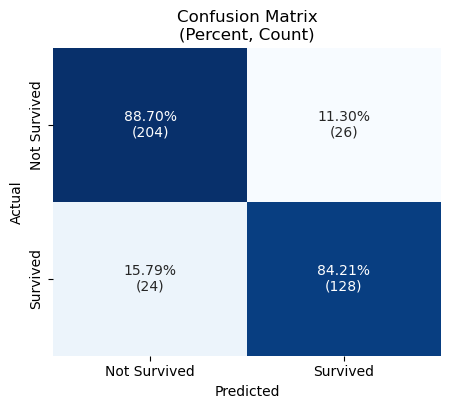


📈 Model Scores:
Log Loss: 0.3632 (Diff from Baseline: 0.0093)
PR AUC: 0.8960 (Diff from Baseline: -0.0098)
ROC AUC: 0.9063 (Diff from Baseline: -0.0052)
F1 Score: 0.8637 (Diff from Baseline: -0.0071)
Precision: 0.8630 (Diff from Baseline: -0.0081)
Recall: 0.8645 (Diff from Baseline: -0.0060)
Accuracy: 0.8691 (Diff from Baseline: -0.0068)


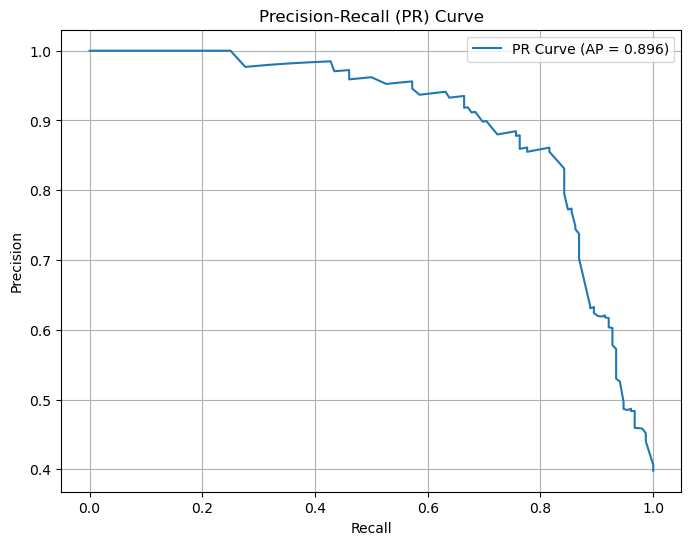

ℹ️ Best threshold for F1 score: 0.373
Max F1 score: 0.838


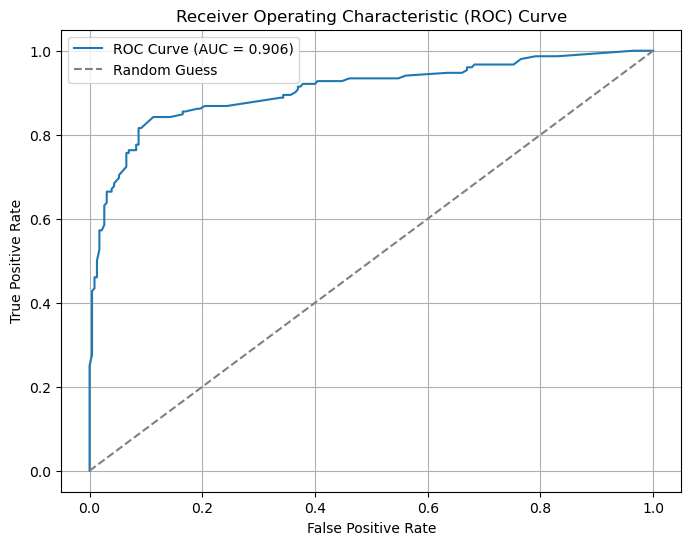

🏃 View run sneaky-crab-2 at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/231754bb57244e019afe0ccea192f0fc
🧪 View experiment at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3
CV Results:
[{'fold': 1, 'best_trial_params': {'C': 4.343957901116486, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 370, 'penalty': 'l2', 'solver': 'liblinear'}, 'log_loss': 0.3559392237153411, 'roc_auc': 0.9100543478260871, 'pr_auc': 0.9050380724416415, 'f1': 0.8769356328257554, 'precision': 0.877368768097245, 'recall': 0.8765160183066362, 'accuracy': 0.8821989528795812}, {'fold': 2, 'best_trial_params': {'C': 4.363382007777653, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 236, 'penalty': 'l2', 'solver': 'saga'}, 'log_loss': 0.3631669125553725, 'roc_auc': 0.9063358123569794, 'pr_auc': 0.8959651355502853, 'f1': 0.8637155007563433, 'precision': 0.8629528366370471, 'recall': 0.8645308924485126, 'accuracy': 0.8691099

[I 2025-06-26 16:52:57,542] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_3



PREPROCESSING AND TRAINING
Preprocessor will generate 139 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 310 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 208 unique rows after deduplication.
Saving clean training set for later use... (208 rows, 139 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (380 rows)


[I 2025-06-26 16:52:58,725] Trial 0 finished with value: 0.6931471805599454 and parameters: {'C': 0.01416539792712367, 'class_weight': None, 'fit_intercept': True, 'max_iter': 558, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.6931471805599454.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.6931
PR AUC: 0.4105
ROC AUC: 0.5000
F1 Score: 0.2910
Precision: 0.2053
Recall: 0.5000
Accuracy: 0.4105
Preprocessor will generate 139 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 310 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 208 unique rows after deduplication.
Saving clean training set for later use... (208 rows, 139 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (380 rows)


...

Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.3537
PR AUC: 0.8963
ROC AUC: 0.9120
F1 Score: 0.8744
Precision: 0.8898
Recall: 0.8665
Accuracy: 0.8816
Preprocessor will generate 139 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 310 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 208 unique rows after deduplication.
Saving clean training set for later use... (208 rows, 139 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (380 rows)


[I 2025-06-26 16:53:32,811] Trial 28 finished with value: 0.4823654948540064 and parameters: {'C': 80.53110913712489, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 397, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 27 with value: 0.35366146059580683.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.4824
PR AUC: 0.8973
ROC AUC: 0.9119
F1 Score: 0.8540
Precision: 0.8524
Recall: 0.8561
Accuracy: 0.8579
Preprocessor will generate 139 features after preprocessing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Dedupe flag is set. Checking for duplicates in the training set...

Original Training Set: 475 rows.
⚠️ Found 310 duplicate rows in the training set after preprocessing.
✅ Resolved duplicates: 208 unique rows after deduplication.
Saving clean training set for later use... (208 rows, 139 features)

PREDICTION EVALUATION ON DEDUPLICATED DATA

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (380 rows)


[I 2025-06-26 16:53:33,951] Trial 29 finished with value: 0.4488137034828912 and parameters: {'C': 0.16572958095588153, 'class_weight': None, 'fit_intercept': True, 'max_iter': 496, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 27 with value: 0.35366146059580683.


Using threshold: 0.366

📈 Model Scores:
Log Loss: 0.4488
PR AUC: 0.8729
ROC AUC: 0.8822
F1 Score: 0.7945
Precision: 0.7932
Recall: 0.8019
Accuracy: 0.7974
Best Trial:
  Value (Log Loss): 0.3537
  Params:
    C: 5.2580246249370415
    class_weight: balanced
    fit_intercept: False
    max_iter: 462
    penalty: l2
    solver: liblinear

Checking for multicollinearity in the processed training set...
⚠️ High Correlation Pairs (|r| > 0.8):
* Pclass_Embarked_1_Q and Class_Sex_Embkd_Age_IsAlone_HasCabin_DeckBin_1_female_Q_Young_Adult_0_1_Upper: 1.00

Preprocessor generated the following 172 features:
* Ticket_Frequency_bin_Shared
* Ticket_Frequency_bin_Unique
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Class_Sex_Embkd_Age_IsAlone_Ha

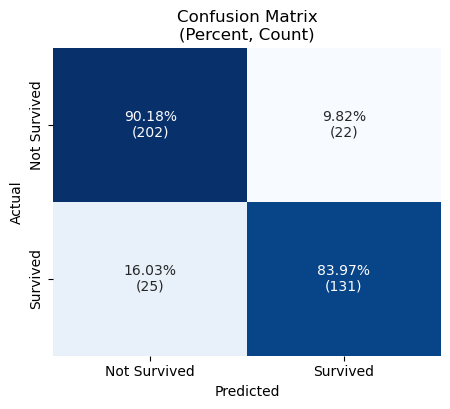


📈 Model Scores:
Log Loss: 0.3425 (Diff from Baseline: -0.0114)
PR AUC: 0.9165 (Diff from Baseline: 0.0108)
ROC AUC: 0.9180 (Diff from Baseline: 0.0065)
F1 Score: 0.8718 (Diff from Baseline: 0.0010)
Precision: 0.8730 (Diff from Baseline: 0.0019)
Recall: 0.8708 (Diff from Baseline: 0.0002)
Accuracy: 0.8763 (Diff from Baseline: 0.0004)


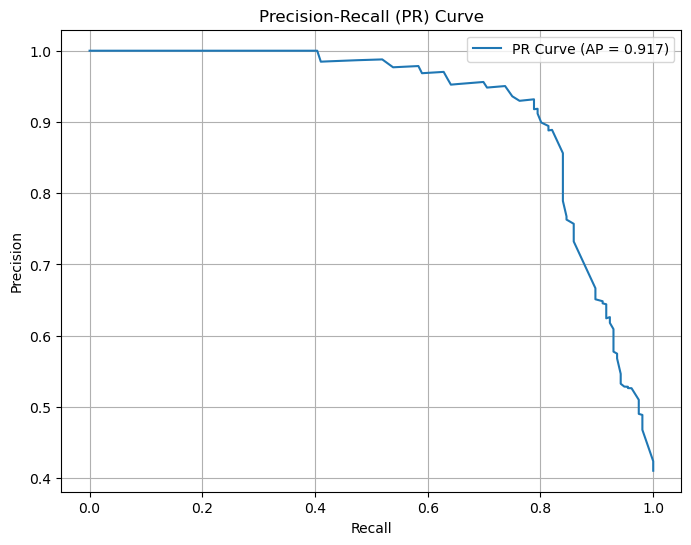

ℹ️ Best threshold for F1 score: 0.486
Max F1 score: 0.854


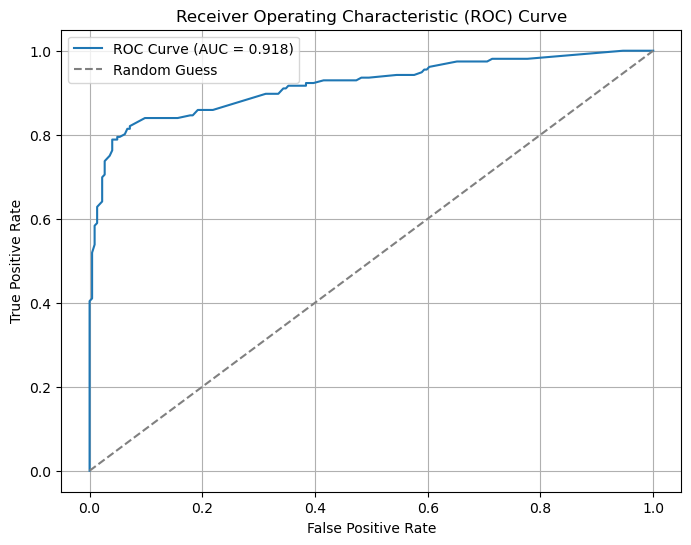

🏃 View run gifted-squirrel-517 at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/6151158fb041465ab7d8a68d889612d6
🧪 View experiment at: http://ec2-3-21-125-83.us-east-2.compute.amazonaws.com:5000/#/experiments/3
CV Results:
[{'fold': 1, 'best_trial_params': {'C': 4.343957901116486, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 370, 'penalty': 'l2', 'solver': 'liblinear'}, 'log_loss': 0.3559392237153411, 'roc_auc': 0.9100543478260871, 'pr_auc': 0.9050380724416415, 'f1': 0.8769356328257554, 'precision': 0.877368768097245, 'recall': 0.8765160183066362, 'accuracy': 0.8821989528795812}, {'fold': 2, 'best_trial_params': {'C': 4.363382007777653, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 236, 'penalty': 'l2', 'solver': 'saga'}, 'log_loss': 0.3631669125553725, 'roc_auc': 0.9063358123569794, 'pr_auc': 0.8959651355502853, 'f1': 0.8637155007563433, 'precision': 0.8629528366370471, 'recall': 0.8645308924485126, 'accuracy': 0.8

In [41]:

cv_results = []
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train[selected_features], y_train)):
    print(f"\nFold {fold + 1}/{outer_cv.n_splits}")
    X_train_fold = X_train[selected_features].iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]
    X_val_fold = X_train[selected_features].iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    with mlflow.start_run():
        mlflow.set_tag("dataset", "X_train_fold")

        print("\n" + "="*50)
        print("PREPROCESSING AND TRAINING")
        print("="*50)

        preprocessor = ColumnTransformer([
            ('fpp', fare_enrichment_pipeline, ['Ticket', 'Fare']),
            ('pclass_embarked_ohe', pclass_embarked_pipeline, ['Pclass', 'Embarked']),
            ('age_ohe', age_pipeline, age_pipeline_cols),
            ('class_sex_embarked_age_isalone_pipeline', class_sex_embarked_age_isalone_pipeline, age_pipeline_cols + ['Embarked', 'Is_Alone', 'HasCabin']),
            ('p1_loner_male_young_adult_pipeline', p1_loner_male_young_adult_pipeline, age_pipeline_cols + ['Is_P1_Loner_Male']),
            ('sex_isalone_ohes_and_male_loner_teen_pipeline', sex_isalone_ohes_and_male_loner_teen_pipeline, age_pipeline_cols + ['Sex_IsAlone']),
            ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features),
            ('passthrough', 'passthrough', ['Is_P3_Loner_Male'])
        ])

        def optuna_objective(trial):

            preprocessor.fit(X_train_fold)
            high_corr_features_to_drop = [
                'Deck_Bin_Unknown Deck',
                # 'Deck_Bin_Rare'
            ]
            feature_names_after_preprocessing = get_feature_names_from_preprocessor(preprocessor, selected_features)
            feature_names_after_preprocessing = [feat for feat in feature_names_after_preprocessing if feat not in high_corr_features_to_drop]
            print(f"Preprocessor will generate {len(feature_names_after_preprocessing)} features after preprocessing.")
            dropper = FeatureDropper(drop_features=high_corr_features_to_drop)
            dropper.set_input_feature_names(feature_names_after_preprocessing)

            trial_model_params = {
                'C': trial.suggest_float("C", 1e-3, 1e2, log=True), 
                'class_weight': trial.suggest_categorical("class_weight", [None, 'balanced']), 
                'fit_intercept': trial.suggest_categorical("fit_intercept", [True, False]), 
                'max_iter': trial.suggest_int("max_iter", 100, 1000), 
                'penalty': trial.suggest_categorical("penalty", ["l1", "l2"]), 
                'solver': trial.suggest_categorical("solver", ["liblinear", "saga"])
            }

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('dropper', dropper),
                ('classifier', DupFreeClassifier(LogisticRegression(**trial_model_params, random_state=42)))
            ])

            mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)

            pipeline.fit(X_train_fold, y_train_fold)

            scores, _, _, _, _ = evaluate_on_deduplicated_data(pipeline, X_train_fold, y_train_fold, selected_features, threshold=0.366, skip_visualizations=True)

            return scores['log_loss']  # Use log_loss as the objective to minimize
        
        study = optuna.create_study(direction="minimize", study_name=f"titanic_ml_from_disaster__abridged_fold_{fold + 1}")
        study.optimize(optuna_objective, n_trials=30)
        
        print("Best Trial:")
        print(f"  Value (Log Loss): {study.best_value:.4f}")
        print("  Params:")
        for key, value in study.best_params.items():
            print(f"    {key}: {value}")
        mlflow.log_params(study.best_params)

        # Plot correlation matrix for fitted features to identify potential multicollinearity issues
        # Print feature pairs with high correlation (> 0.8)
        X_train_processed = pipeline.named_steps['classifier'].train_X_clean_
        X_train_processed.columns = feature_names_after_preprocessing
        print("\nChecking for multicollinearity in the processed training set...")
        correlation_matrix = X_train_processed.corr()
        high_corr_pairs = []
        for i in range(len(feature_names_after_preprocessing)):
            for j in range(i + 1, len(feature_names_after_preprocessing)):
                if abs(correlation_matrix.iloc[i, j]) > 0.8:
                    high_corr_pairs.append((feature_names_after_preprocessing[i], feature_names_after_preprocessing[j], correlation_matrix.iloc[i, j]))
        if high_corr_pairs:
            print("⚠️ High Correlation Pairs (|r| > 0.8):")
            for feat1, feat2, corr in high_corr_pairs:
                print(f"* {feat1} and {feat2}: {corr:.2f}") 
        else:
            print("✅ No high correlation pairs found (|r| <= 0.8).") 

        print(f"\nPreprocessor generated the following {len(feature_names_after_preprocessing)} features:")
        for i, feat in enumerate(feature_names_after_preprocessing):
            print(f"* {feat}")
            mlflow.log_param(f"feature_{i}", feat)

        scores, _, _, _, _ = evaluate_on_deduplicated_data(pipeline, X_train_fold, y_train_fold, selected_features, threshold=0.366, training_baseline_metrics=baseline_metrics)

        cv_results.append({
            'fold': fold + 1,
            'best_trial_params': study.best_params,
            'log_loss': scores['log_loss'],
            'roc_auc': scores['roc_auc'],
            'pr_auc': scores['pr_auc'],
            'f1': scores['f1'],
            'precision': scores['precision'],
            'recall': scores['recall'],
            'accuracy': scores['accuracy']
        })

    print("CV Results:")
    print(cv_results)

#### Dev Set Evaluation

In [42]:
# # Perform hyperparameter tuning using CV within dev set
# with mlflow.start_run():
#     mlflow.set_tag("dataset", "X_dev")

#     mlflow.log_params(default_model_params)
#     mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)
#     #mlflow.log_param("num_fare_bins", num_fare_bins)

#     print(f"\nEvaluating model with {len(feature_names_after_preprocessing)} features:")
#     for i, feat in enumerate(feature_names_after_preprocessing):
#         print(f"* {feat}")
#         mlflow.log_param(f"feature_{i}", feat)

#     # Reuse preprocessor and classifier
#     y_pred = pipeline.predict(X_dev[selected_features])
#     y_pred_proba = pipeline.predict_proba(X_dev[selected_features])[:, 1]

#     dev_logloss = log_loss(y_dev, pipeline.predict_proba(X_dev[selected_features]))
#     dev_rocauc = roc_auc_score(y_dev, y_pred_proba)
#     dev_prauc = average_precision_score(y_dev, y_pred_proba)
#     dev_acc  = accuracy_score(y_dev, y_pred)
#     dev_prec = precision_score(y_dev, y_pred, average='macro')
#     dev_rec  = recall_score(y_dev, y_pred, average='macro')
#     dev_f1   = f1_score(y_dev, y_pred, average='macro')
    
#     mlflow.log_metrics({ 
#         "log_loss": dev_logloss,
#         "roc_auc": dev_rocauc,
#         "pr_auc": dev_prauc,
#         "f1": dev_f1,
#         "accuracy": dev_acc,
#         "precision": dev_prec,
#         "recall": dev_rec
#     })

#     print("\nDev Set Scores:")
#     print("Dev Log Loss:", dev_logloss)
#     print("Dev ROC AUC:", dev_rocauc)
#     print("Dev PR AUC:", dev_prauc)
#     print("Dev F1:", dev_f1)
#     print("Dev Precision:", dev_prec)
#     print("Dev Recall   :", dev_rec)
#     print("Dev Accuracy :", dev_acc)
#     print()

#     # Diagnostic Outputs
#     X_dev_dense_processed = pipeline.named_steps['preprocessor'].transform(X_dev[selected_features]).toarray()
#     X_dev_processed = pd.DataFrame(X_dev_dense_processed, columns=feature_names_after_preprocessing)
#     print_diagnostics(pipeline.named_steps['classifier'], X_dev_processed, y_dev, y_pred, y_pred_proba, feature_names_after_preprocessing)   


#### Evaluation Summary

In [43]:
# # Create table summarizing evaluation scores across training, dev, cv, and holdout sets
# def create_evaluation_summary_table_and_plot():
#     """
#     Prints pre- and post-hyperparameter tuning bias/variance,
#     returns evaluation summary table, and plots evaluation metrics across all data splits.
#     """

#     # Create summary table
#     data = {
#         'Set': ['Training', 'Dev', 'Grid Search CV'],
#         'Log Loss': [training_logloss, dev_logloss, cv_logloss_mean],
#         'ROC AUC': [training_rocauc, dev_rocauc, np.nan],  # ROC AUC not computed for CV
#         'PR AUC': [training_prauc, dev_prauc, np.nan],  # PR AUC not computed for CV
#         'F1 Score': [training_f1, dev_f1, cv_f1_mean],
#         'Precision': [training_prec, dev_prec, cv_prec_mean],
#         'Recall': [training_rec, dev_rec, cv_rec_mean],
#         'Accuracy': [training_acc, dev_acc, cv_acc_mean],
#     }
#     summary_df = pd.DataFrame(data)

#     print("\nEvaluation Summary Table:")
#     print(summary_df)

#     # Bias/variance report
#     print(f"\nModel Metric Variance (train - holdout) Report:")
#     print(f"Log Loss Variance: {(training_logloss - dev_logloss):.4f}")
#     print(f"ROC AUC Variance: {(training_rocauc - dev_rocauc):.4f}")
#     print(f"PR AUC Variance: {(training_prauc - dev_prauc):.4f}")
#     print(f"F1 Score Variance: {(training_f1 - dev_f1):.4f}")
#     print(f"Precision Variance: {(training_prec - dev_prec):.4f}")
#     print(f"Recall Variance: {(training_rec - dev_rec):.4f}")
#     print(f"Accuracy Variance: {(training_acc - dev_acc):.4f}")

#     print()

#     # Plotting
#     plt.figure(figsize=(6, 4))
#     for metric in ['Log Loss', 'ROC AUC', 'PR AUC', 'F1 Score', 'Precision', 'Recall', 'Accuracy']:
#         plt.plot(summary_df['Set'], summary_df[metric], marker='o', label=metric)

#     plt.title(f'{pipeline.named_steps['classifier'].estimator_.__class__.__name__} Performance: Training vs Dev vs CV vs Holdout')
#     plt.ylabel('Score')
#     plt.xlabel('Evaluation Set')
#     plt.ylim(0.3, 0.87)
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


# create_evaluation_summary_table_and_plot()

### Submission File Generation

In [44]:
# Retrain on full training set and apply X_test sample weights
full_train_set = training_set_df.copy()
X_full_train_set = full_train_set.drop(columns=['Survived'])
X_full_train_set = engineer_features(X_full_train_set)
y_full_train_set = full_train_set['Survived']
print(X_full_train_set.shape, y_full_train_set.shape)

# TODO Resolve the issue with sample weights
#pipeline.fit(X_full_train_set[selected_features], y_full_train_set, classifier__dedupe=False, classifier__sample_weight=X_test_sample_weights)

(891, 33) (891,)


In [45]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [46]:
X_test[X_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Cabin_Number,Cabin_Side,Cabin_Missing,Age_Missing,Is_Child,Is_Loner_P3_Male_Southampton,Is_P3_Loner_Male,Is_P1_Loner_Male,Sex_IsAlone,Pclass_Sex
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,...,0,Starboard,1,0,0,1,1,0,male_1,3_male


In [47]:
X_test['Fare'] = X_test['Fare'].fillna(X_test.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [48]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Cabin    327
dtype: int64

In [49]:
X_test = engineer_features(X_test)

In [50]:
submission = pd.DataFrame({
    'PassengerId': X_test['PassengerId'],
    'Survived': pipeline.predict(X_test[selected_features])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

✂️ Dropping features: ['Deck_Bin_Unknown Deck']
Saving clean predicted set for post-analysis... (418 rows)


c:\Users\pault\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


-----------

In [51]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size